<a href="https://colab.research.google.com/github/kasrasa/ViT-VLM-experiments/blob/ViT-Experiments/ViT_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q transformers torch
!pip install -q timm
!pip install -q evaluate
!pip install -q peft
!pip install --upgrade -q torchao
!pip install -q scikit-learn
!pip install -q matplotlib seaborn accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 44.1 MB/s eta 0:00:00


In [2]:
import os

# Set to True to always fine-tune, False to load existing checkpoints if available
FORCE_FINE_TUNING = True

In [3]:
from transformers import DefaultDataCollator

data_collator = DefaultDataCollator()

In [4]:
import evaluate
accuracy = evaluate.load("accuracy")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [7]:
from datasets import load_dataset, DatasetDict
from collections import defaultdict, Counter
import random
import numpy as np

# -----------------------------
# Balanced Food101 subset config
# -----------------------------
DATASET_NAME = "ethz/food101"
NUM_SELECTED_CLASSES = 20
SAMPLES_PER_CLASS = 250
TEST_SIZE = 0.20
SEED = 42

# Load the full Food101 training split.
# We use the train split and create our own stratified train/validation split
# because this experiment is meant to compare fine-tuning strategies cheaply.
food_full_train = load_dataset(DATASET_NAME, split="train")
original_labels = food_full_train.features["label"].names

rng = random.Random(SEED)

# Group dataset indices by original Food101 class id
label_to_indices = defaultdict(list)
for idx, label_id in enumerate(food_full_train["label"]):
    label_to_indices[int(label_id)].append(idx)

# Keep only classes that have enough examples
eligible_label_ids = [
    label_id
    for label_id, indices in label_to_indices.items()
    if len(indices) >= SAMPLES_PER_CLASS
]

if len(eligible_label_ids) < NUM_SELECTED_CLASSES:
    raise ValueError(
        f"Only {len(eligible_label_ids)} classes have at least "
        f"{SAMPLES_PER_CLASS} samples. Need {NUM_SELECTED_CLASSES}."
    )

# Select 20 classes reproducibly
selected_old_label_ids = sorted(rng.sample(eligible_label_ids, NUM_SELECTED_CLASSES))

# Select exactly 250 images per selected class
selected_indices = []
for old_label_id in selected_old_label_ids:
    indices = label_to_indices[old_label_id].copy()
    rng.shuffle(indices)
    selected_indices.extend(indices[:SAMPLES_PER_CLASS])

rng.shuffle(selected_indices)

food_subset = food_full_train.select(selected_indices)

print(f"Total selected images: {len(food_subset)}")
print(f"Selected classes: {len(selected_old_label_ids)}")
print("Selected class names:")
for old_label_id in selected_old_label_ids:
    print(f"  old_id={old_label_id:3d} -> {original_labels[old_label_id]}")

# Stratified split while labels are still original Food101 label IDs
food = food_subset.train_test_split(
    test_size=TEST_SIZE,
    shuffle=True,
    seed=SEED,
    stratify_by_column="label",
)

# Remap selected original labels to contiguous labels 0..19.
# This is important because the classifier head will have exactly 20 outputs.
old_to_new = {
    old_label_id: new_label_id
    for new_label_id, old_label_id in enumerate(selected_old_label_ids)
}

new_to_old = {
    new_label_id: old_label_id
    for old_label_id, new_label_id in old_to_new.items()
}

labels = [
    original_labels[new_to_old[new_label_id]]
    for new_label_id in range(NUM_SELECTED_CLASSES)
]

id2label = {
    new_label_id: label_name
    for new_label_id, label_name in enumerate(labels)
}

label2id = {
    label_name: new_label_id
    for new_label_id, label_name in id2label.items()
}

def remap_label(example):
    example["label"] = old_to_new[int(example["label"])]
    return example

food = DatasetDict({
    "train": food["train"].map(remap_label),
    "test": food["test"].map(remap_label),
})

# Sanity checks
train_counts = Counter(food["train"]["label"])
test_counts = Counter(food["test"]["label"])

print("\nAfter remapping:")
print(f"Train size: {len(food['train'])}")
print(f"Validation size: {len(food['test'])}")
print(f"Number of labels: {len(labels)}")
print(f"Train class counts: {sorted(train_counts.items())}")
print(f"Validation class counts: {sorted(test_counts.items())}")

assert len(food["train"]) + len(food["test"]) == NUM_SELECTED_CLASSES * SAMPLES_PER_CLASS
assert set(train_counts.keys()) == set(range(NUM_SELECTED_CLASSES))
assert set(test_counts.keys()) == set(range(NUM_SELECTED_CLASSES))


Generating train split:   0%|          | 0/75750 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/25250 [00:00<?, ? examples/s]

Total selected images: 5000
Selected classes: 20
Selected class names:
  old_id= 10 -> bruschetta
  old_id= 11 -> caesar_salad
  old_id= 13 -> caprese_salad
  old_id= 15 -> ceviche
  old_id= 21 -> chocolate_cake
  old_id= 24 -> clam_chowder
  old_id= 31 -> donuts
  old_id= 33 -> edamame
  old_id= 34 -> eggs_benedict
  old_id= 40 -> french_fries
  old_id= 44 -> fried_rice
  old_id= 53 -> hamburger
  old_id= 54 -> hot_and_sour_soup
  old_id= 58 -> ice_cream
  old_id= 59 -> lasagna
  old_id= 64 -> miso_soup
  old_id= 72 -> pancakes
  old_id= 74 -> peking_duck
  old_id= 97 -> takoyaki
  old_id= 99 -> tuna_tartare


Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]


After remapping:
Train size: 4000
Validation size: 1000
Number of labels: 20
Train class counts: [(0, 200), (1, 200), (2, 200), (3, 200), (4, 200), (5, 200), (6, 200), (7, 200), (8, 200), (9, 200), (10, 200), (11, 200), (12, 200), (13, 200), (14, 200), (15, 200), (16, 200), (17, 200), (18, 200), (19, 200)]
Validation class counts: [(0, 50), (1, 50), (2, 50), (3, 50), (4, 50), (5, 50), (6, 50), (7, 50), (8, 50), (9, 50), (10, 50), (11, 50), (12, 50), (13, 50), (14, 50), (15, 50), (16, 50), (17, 50), (18, 50), (19, 50)]


In [8]:
# Label mappings for the 20-class balanced Food101 subset.
# These are already created in the dataset-loading cell above.
# The classifier head should use len(labels) == 20.

print(f"Number of selected labels: {len(labels)}")
print("id2label:")
for class_id, class_name in id2label.items():
    print(f"  {class_id}: {class_name}")

print("\nlabel2id:")
for class_name, class_id in label2id.items():
    print(f"  {class_name}: {class_id}")


Number of selected labels: 20
id2label:
  0: bruschetta
  1: caesar_salad
  2: caprese_salad
  3: ceviche
  4: chocolate_cake
  5: clam_chowder
  6: donuts
  7: edamame
  8: eggs_benedict
  9: french_fries
  10: fried_rice
  11: hamburger
  12: hot_and_sour_soup
  13: ice_cream
  14: lasagna
  15: miso_soup
  16: pancakes
  17: peking_duck
  18: takoyaki
  19: tuna_tartare

label2id:
  bruschetta: 0
  caesar_salad: 1
  caprese_salad: 2
  ceviche: 3
  chocolate_cake: 4
  clam_chowder: 5
  donuts: 6
  edamame: 7
  eggs_benedict: 8
  french_fries: 9
  fried_rice: 10
  hamburger: 11
  hot_and_sour_soup: 12
  ice_cream: 13
  lasagna: 14
  miso_soup: 15
  pancakes: 16
  peking_duck: 17
  takoyaki: 18
  tuna_tartare: 19


In [9]:
from torchvision.transforms import (
    RandomResizedCrop,
    Resize,
    CenterCrop,
    Compose,
    Normalize,
    ToTensor,
)

def get_image_size(image_processor):
    if "shortest_edge" in image_processor.size:
        return image_processor.size["shortest_edge"]
    return image_processor.size["height"]

def apply_transforms(examples, image_processor, is_train=True):
    image_size = get_image_size(image_processor)
    normalize = Normalize(
        mean=image_processor.image_mean,
        std=image_processor.image_std,
    )

    if is_train:
        transform = Compose([
            RandomResizedCrop(image_size),
            ToTensor(),
            normalize,
        ])
    else:
        transform = Compose([
            Resize(image_size),
            CenterCrop(image_size),
            ToTensor(),
            normalize,
        ])

    examples["pixel_values"] = [
        transform(img.convert("RGB")) for img in examples["image"]
    ]
    del examples["image"]
    return examples

## Update `compute_metrics` Function

This section updates the `compute_metrics` function to include the F1-score in addition to accuracy. This provides a more comprehensive evaluation metric, especially for imbalanced datasets.

In [10]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

def softmax_np(logits):
    """
    Numerically stable softmax.
    """
    logits = logits - np.max(logits, axis=1, keepdims=True)
    exp_logits = np.exp(logits)
    return exp_logits / np.sum(exp_logits, axis=1, keepdims=True)


def expected_calibration_error(probs, labels, n_bins=10):
    """
    Expected Calibration Error.

    If the model says it is 80% confident, we want it to be correct
    about 80% of the time. ECE measures this mismatch.
    """
    confidences = np.max(probs, axis=1)
    predictions = np.argmax(probs, axis=1)
    correct = predictions == labels

    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0

    for i in range(n_bins):
        lower = bin_edges[i]
        upper = bin_edges[i + 1]

        if i == 0:
            in_bin = (confidences >= lower) & (confidences <= upper)
        else:
            in_bin = (confidences > lower) & (confidences <= upper)

        prop_in_bin = np.mean(in_bin)

        if prop_in_bin > 0:
            avg_confidence = np.mean(confidences[in_bin])
            avg_accuracy = np.mean(correct[in_bin])
            ece += prop_in_bin * abs(avg_confidence - avg_accuracy)

    return float(ece)


def compute_metrics(eval_pred):
    """
    Metrics used during Trainer evaluation.

    Includes:
    - accuracy
    - macro F1
    - weighted F1
    - top-5 accuracy
    - confidence statistics
    - ECE calibration metric
    - NLL
    - multiclass Brier score
    """
    logits = eval_pred.predictions

    # Some Hugging Face models may return predictions as a tuple.
    if isinstance(logits, tuple):
        logits = logits[0]

    labels = eval_pred.label_ids
    predictions = np.argmax(logits, axis=1)
    probs = softmax_np(logits)

    num_classes = probs.shape[1]
    k = min(5, num_classes)

    top_k_predictions = np.argsort(probs, axis=1)[:, -k:]
    top_k_accuracy = np.mean([
        labels[i] in top_k_predictions[i]
        for i in range(len(labels))
    ])

    top1_confidence = np.max(probs, axis=1)

    sorted_probs = np.sort(probs, axis=1)
    top2_confidence = sorted_probs[:, -2] if num_classes > 1 else np.zeros_like(top1_confidence)
    top1_top2_margin = top1_confidence - top2_confidence

    correct_mask = predictions == labels
    wrong_mask = ~correct_mask

    correct_mean_confidence = float(np.mean(top1_confidence[correct_mask])) if np.any(correct_mask) else 0.0
    wrong_mean_confidence = float(np.mean(top1_confidence[wrong_mask])) if np.any(wrong_mask) else 0.0

    # Negative log likelihood for the true class
    eps = 1e-12
    true_class_probs = probs[np.arange(len(labels)), labels]
    nll = -np.mean(np.log(np.clip(true_class_probs, eps, 1.0)))

    # Multiclass Brier score
    one_hot = np.zeros_like(probs)
    one_hot[np.arange(len(labels)), labels] = 1.0
    brier_score = np.mean(np.sum((probs - one_hot) ** 2, axis=1))

    return {
        "accuracy": accuracy_score(labels, predictions),
        "macro_f1": f1_score(labels, predictions, average="macro", zero_division=0),
        "weighted_f1": f1_score(labels, predictions, average="weighted", zero_division=0),

        # Keep this alias so your existing summary table does not break
        "f1": f1_score(labels, predictions, average="weighted", zero_division=0),

        "top_5_accuracy": float(top_k_accuracy),
        "mean_top1_confidence": float(np.mean(top1_confidence)),
        "mean_top1_top2_margin": float(np.mean(top1_top2_margin)),
        "correct_mean_confidence": correct_mean_confidence,
        "wrong_mean_confidence": wrong_mean_confidence,
        "ece": expected_calibration_error(probs, labels, n_bins=10),
        "nll": float(nll),
        "brier_score": float(brier_score),
    }

## Define Parameter Counting Utility

This section defines a Python function to count and display the number of trainable parameters in a given PyTorch model. This function will be reused at various stages to track model complexity.

This function `count_parameters` iterates through model parameters, sums the elements of those that require gradients, and then prints the result in millions.

In [11]:
def count_parameters(model):
    """
    Counts and displays the number of trainable parameters in a PyTorch model.
    """
    num_params_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total_params = sum(p.numel() for p in model.parameters())
    print(f"Number of trainable parameters: {num_params_trainable:,} ({num_params_trainable / 1e6:.2f} million)")
    print(f"Total parameters: {total_params:,} ({total_params / 1e6:.2f} million)")


## Define Reusable Evaluation and Plotting Function

This section creates a function that takes a trained model, a dataset, and label mappings as input, computes predictions, calculates accuracy and F1-score, and generates a confusion matrix. This function will be used to evaluate all fine-tuned models on both Food101 and CIFAR-10 datasets.

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import pandas as pd

def evaluate_and_plot(
    model,
    trainer,
    dataset,
    id2label_mapping,
    dataset_name,
    num_labels,
    model_display_name,
    training_time=None,
    normalize_cm=False,
):
    print(f"\n--- Evaluating {model_display_name} on {dataset_name} ---")

    predictions_output = trainer.predict(dataset)

    logits = predictions_output.predictions
    if isinstance(logits, tuple):
        logits = logits[0]

    labels = predictions_output.label_ids
    predicted_labels = np.argmax(logits, axis=1)
    probs = softmax_np(logits)

    metrics = compute_metrics(predictions_output)

    # Add loss from Trainer prediction output if available
    eval_loss = predictions_output.metrics.get("test_loss", None)
    if eval_loss is not None:
        metrics["eval_loss"] = eval_loss

    print("\nCore metrics:")
    print(f"Accuracy:                {metrics['accuracy']:.4f}")
    print(f"Macro F1:                {metrics['macro_f1']:.4f}")
    print(f"Weighted F1:             {metrics['weighted_f1']:.4f}")
    print(f"Top-5 Accuracy:          {metrics['top_5_accuracy']:.4f}")

    if eval_loss is not None:
        print(f"Eval Loss:               {eval_loss:.4f}")

    print("\nConfidence / calibration metrics:")
    print(f"Mean Top-1 Confidence:   {metrics['mean_top1_confidence']:.4f}")
    print(f"Mean Top1-Top2 Margin:   {metrics['mean_top1_top2_margin']:.4f}")
    print(f"Correct Mean Confidence: {metrics['correct_mean_confidence']:.4f}")
    print(f"Wrong Mean Confidence:   {metrics['wrong_mean_confidence']:.4f}")
    print(f"ECE:                     {metrics['ece']:.4f}")
    print(f"NLL:                     {metrics['nll']:.4f}")
    print(f"Brier Score:             {metrics['brier_score']:.4f}")

    if training_time is not None:
        print(f"\nTraining time for {model_display_name}: {training_time:.2f} seconds")

    print("\nLabel sanity check:")
    print(f"Number of unique true labels:      {len(np.unique(labels))}")
    print(f"Number of unique predicted labels: {len(np.unique(predicted_labels))}")

    # -----------------------------
    # Confidence analysis dataframe
    # -----------------------------
    top1_conf = np.max(probs, axis=1)
    sorted_probs = np.sort(probs, axis=1)
    top2_conf = sorted_probs[:, -2] if probs.shape[1] > 1 else np.zeros_like(top1_conf)
    margins = top1_conf - top2_conf
    correct = predicted_labels == labels

    confidence_df = pd.DataFrame({
        "true_label_id": labels,
        "pred_label_id": predicted_labels,
        "true_label": [id2label_mapping[int(i)] for i in labels],
        "pred_label": [id2label_mapping[int(i)] for i in predicted_labels],
        "top1_confidence": top1_conf,
        "top2_confidence": top2_conf,
        "top1_top2_margin": margins,
        "correct": correct,
    })

    print("\nConfidence summary:")
    display(
        confidence_df.groupby("correct")[[
            "top1_confidence",
            "top1_top2_margin"
        ]].agg(["mean", "median", "min", "max", "count"]).round(4)
    )

    print("\nMost confident wrong predictions:")
    wrong_predictions = confidence_df[confidence_df["correct"] == False]
    if len(wrong_predictions) > 0:
        display(
            wrong_predictions
            .sort_values("top1_confidence", ascending=False)
            .head(10)
            .round(4)
        )
    else:
        print("No wrong predictions found.")

    print("\nLowest-margin predictions:")
    display(
        confidence_df
        .sort_values("top1_top2_margin", ascending=True)
        .head(10)
        .round(4)
    )

    # -----------------------------
    # Full confusion matrix
    # -----------------------------
    all_label_ids = list(range(num_labels))
    target_names = [id2label_mapping[i] for i in all_label_ids]

    cm = confusion_matrix(
        labels,
        predicted_labels,
        labels=all_label_ids,
    )

    if normalize_cm:
        cm_to_plot = cm.astype("float") / cm.sum(axis=1, keepdims=True)
        cm_to_plot = np.nan_to_num(cm_to_plot)
    else:
        cm_to_plot = cm

    plt.figure(figsize=(12, 10))

    if num_labels > 20:
        sns.heatmap(
            cm_to_plot,
            cmap="Blues",
            xticklabels=False,
            yticklabels=False,
            cbar=True,
        )
        plt.title(
            f"Confusion Matrix for {model_display_name} on {dataset_name}\n"
            f"Labels omitted because there are {num_labels} classes"
        )
    else:
        sns.heatmap(
            cm_to_plot,
            annot=True,
            fmt=".2f" if normalize_cm else "g",
            cmap="Blues",
            xticklabels=target_names,
            yticklabels=target_names,
        )
        plt.title(f"Confusion Matrix for {model_display_name} on {dataset_name}")

    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.tight_layout()
    plt.show()

    # -----------------------------
    # Classification report
    # -----------------------------
    print(f"\n--- Per-class metrics for {model_display_name} ---")

    report = classification_report(
        labels,
        predicted_labels,
        labels=all_label_ids,
        target_names=target_names,
        output_dict=True,
        zero_division=0,
    )

    report_df = pd.DataFrame(report).transpose()

    class_metrics_df = report_df.loc[target_names].copy()
    class_metrics_df["f1-score"] = pd.to_numeric(class_metrics_df["f1-score"], errors="coerce")

    print("\nTop 10 weakest classes by F1-score:")
    weakest_classes = class_metrics_df.sort_values("f1-score", ascending=True).head(10)
    display(weakest_classes[["precision", "recall", "f1-score", "support"]].round(4))

    print("\nTop 10 strongest classes by F1-score:")
    strongest_classes = class_metrics_df.sort_values("f1-score", ascending=False).head(10)
    display(strongest_classes[["precision", "recall", "f1-score", "support"]].round(4))

    # -----------------------------
    # Refined confusion matrix for weakest classes
    # -----------------------------
    weakest_class_names = weakest_classes.index.tolist()
    weakest_label_ids = [target_names.index(name) for name in weakest_class_names]

    if len(weakest_label_ids) > 0:
        mask = np.isin(labels, weakest_label_ids)
        filtered_true = labels[mask]
        filtered_pred = predicted_labels[mask]

        if len(filtered_true) > 0:
            refined_cm = confusion_matrix(
                filtered_true,
                filtered_pred,
                labels=weakest_label_ids,
            )

            if normalize_cm:
                refined_cm_to_plot = refined_cm.astype("float") / refined_cm.sum(axis=1, keepdims=True)
                refined_cm_to_plot = np.nan_to_num(refined_cm_to_plot)
            else:
                refined_cm_to_plot = refined_cm

            plt.figure(figsize=(10, 8))
            sns.heatmap(
                refined_cm_to_plot,
                annot=True,
                fmt=".2f" if normalize_cm else "g",
                cmap="Reds",
                xticklabels=weakest_class_names,
                yticklabels=weakest_class_names,
            )
            plt.title(
                f"Refined Confusion Matrix for Weakest Classes\n"
                f"{model_display_name} on {dataset_name}"
            )
            plt.xlabel("Predicted label")
            plt.ylabel("True label")
            plt.tight_layout()
            plt.show()
        else:
            print("No samples found for weakest classes.")

    # -----------------------------
    # Plotting Train vs. Validation Loss
    # -----------------------------
    train_losses_plot = []
    eval_losses_plot = []
    train_steps_plot = []
    eval_steps_plot = []

    # Get log history from the trainer
    log_history = trainer.state.log_history

    for entry in log_history:
        if 'loss' in entry and 'step' in entry:
            train_losses_plot.append(entry['loss'])
            train_steps_plot.append(entry['step'])
        if 'eval_loss' in entry and 'step' in entry:
            eval_losses_plot.append(entry['eval_loss'])
            eval_steps_plot.append(entry['step'])

    if train_steps_plot or eval_steps_plot:
        plt.figure(figsize=(10, 6))
        if train_steps_plot:
            plt.plot(train_steps_plot, train_losses_plot, label='Training Loss', marker='o', linestyle='-', markersize=4)
        if eval_steps_plot:
            plt.plot(eval_steps_plot, eval_losses_plot, label='Validation Loss', marker='x', linestyle='--', markersize=4)

        plt.title(f'{model_display_name} - Training vs. Validation Loss Over Steps')
        plt.xlabel('Training Steps')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()
    else:
        print(f"No loss history found for {model_display_name} to plot.")


    metrics["classification_report_df"] = report_df
    metrics["confidence_df"] = confidence_df

    return metrics

In [13]:
from transformers.trainer_utils import get_last_checkpoint
import os
import json
import torch
from safetensors.torch import load_file

try:
    from peft import set_peft_model_state_dict
except Exception:
    set_peft_model_state_dict = None


def has_model_weights(path):
    """
    Checks whether a directory contains saved model weights.
    Supports regular HF model weights and PEFT/LoRA adapter weights.
    """
    if path is None or not os.path.isdir(path):
        return False

    possible_files = [
        "pytorch_model.bin",
        "model.safetensors",
        "adapter_model.bin",
        "adapter_model.safetensors",
    ]

    return any(os.path.exists(os.path.join(path, f)) for f in possible_files)


def load_weights_into_existing_model(model_instance, checkpoint_path, model_name_for_log):
    """
    Loads saved weights into the existing model object.

    This is safer than only detecting that a model exists and then skipping training,
    because we need the current notebook model object to actually contain the saved weights.
    """
    print(f"Loading saved weights for {model_name_for_log} from: {checkpoint_path}")

    # Case 1: PEFT / LoRA adapter checkpoint
    adapter_safetensors = os.path.join(checkpoint_path, "adapter_model.safetensors")
    adapter_bin = os.path.join(checkpoint_path, "adapter_model.bin")

    if os.path.exists(adapter_safetensors) or os.path.exists(adapter_bin):
        if set_peft_model_state_dict is None:
            raise ImportError(
                "PEFT adapter weights found, but `set_peft_model_state_dict` could not be imported."
            )

        if os.path.exists(adapter_safetensors):
            state_dict = load_file(adapter_safetensors)
        else:
            state_dict = torch.load(adapter_bin, map_location="cpu")

        set_peft_model_state_dict(model_instance, state_dict)
        print(f"Loaded PEFT/LoRA adapter weights for {model_name_for_log}.")
        return True

    # Case 2: regular Hugging Face / PyTorch checkpoint
    model_safetensors = os.path.join(checkpoint_path, "model.safetensors")
    model_bin = os.path.join(checkpoint_path, "pytorch_model.bin")

    if os.path.exists(model_safetensors):
        state_dict = load_file(model_safetensors)
    elif os.path.exists(model_bin):
        state_dict = torch.load(model_bin, map_location="cpu")
    else:
        raise FileNotFoundError(f"No supported model weight file found in {checkpoint_path}")

    load_result = model_instance.load_state_dict(state_dict, strict=False)

    missing_keys = list(load_result.missing_keys)
    unexpected_keys = list(load_result.unexpected_keys)

    if len(missing_keys) > 0:
        print(f"Warning: missing keys while loading {model_name_for_log}:")
        print(missing_keys[:20])
        if len(missing_keys) > 20:
            print(f"... and {len(missing_keys) - 20} more")

    if len(unexpected_keys) > 0:
        print(f"Warning: unexpected keys while loading {model_name_for_log}:")
        print(unexpected_keys[:20])
        if len(unexpected_keys) > 20:
            print(f"... and {len(unexpected_keys) - 20} more")

    print(f"Loaded regular model weights for {model_name_for_log}.")
    return True


def conditional_train_model(model_instance, trainer_instance, training_args_instance, model_name_for_log):
    """
    Trains, resumes, or loads a model depending on checkpoint availability.

    Behavior:
    - If FORCE_FINE_TUNING=True:
        Start training from the current model initialization.
    - If FORCE_FINE_TUNING=False and a final model exists in output_dir:
        Load the final saved model weights into the current model and skip training.
    - If FORCE_FINE_TUNING=False and only a checkpoint-* folder exists:
        Resume training from the latest checkpoint.
    - After training:
        Save the final/best model to output_dir for future reuse.

    Returns:
    - train_runtime as a float, so your existing notebook summary code still works.
    """
    checkpoint_dir = training_args_instance.output_dir
    os.makedirs(checkpoint_dir, exist_ok=True)

    latest_checkpoint = get_last_checkpoint(checkpoint_dir) if os.path.isdir(checkpoint_dir) else None

    final_model_exists = has_model_weights(checkpoint_dir)
    latest_checkpoint_exists = has_model_weights(latest_checkpoint)

    print(f"\n--- Conditional training check for {model_name_for_log} ---")
    print(f"Output directory: {checkpoint_dir}")
    print(f"FORCE_FINE_TUNING: {FORCE_FINE_TUNING}")
    print(f"Final model exists at root: {final_model_exists}")
    print(f"Latest checkpoint: {latest_checkpoint}")
    print(f"Latest checkpoint has weights: {latest_checkpoint_exists}")

    train_runtime = 0.0

    # Case 1: Load final saved model and skip training
    if final_model_exists and not FORCE_FINE_TUNING:
        try:
            load_weights_into_existing_model(
                model_instance=model_instance,
                checkpoint_path=checkpoint_dir,
                model_name_for_log=model_name_for_log,
            )
            trainer_instance.model = model_instance
            print(f"Skipping training for {model_name_for_log}; loaded final saved model.")
            return train_runtime
        except Exception as e:
            print(f"Could not load final saved model for {model_name_for_log}: {e}")
            print("Will try to resume from latest checkpoint if available, otherwise train from scratch.")

    # Case 2: Force fresh training
    if FORCE_FINE_TUNING:
        print(f"Starting fresh fine-tuning for {model_name_for_log}.")
        train_result = trainer_instance.train(resume_from_checkpoint=None)

    # Case 3: Resume from checkpoint
    elif latest_checkpoint_exists:
        print(f"Resuming training for {model_name_for_log} from: {latest_checkpoint}")
        train_result = trainer_instance.train(resume_from_checkpoint=latest_checkpoint)

    # Case 4: No saved weights found
    else:
        print(f"No usable saved model/checkpoint found for {model_name_for_log}. Starting training.")
        train_result = trainer_instance.train()

    train_runtime = float(train_result.metrics.get("train_runtime", 0.0))

    print(f"Training complete for {model_name_for_log}.")
    print(f"Train runtime: {train_runtime:.2f} seconds")

    # Save final/best model at the root output_dir.
    # With load_best_model_at_end=True, trainer.model should already be the best model.
    print(f"Saving final model for {model_name_for_log} to: {checkpoint_dir}")
    trainer_instance.save_model(checkpoint_dir)

    # Save training metrics for reference.
    metrics_path = os.path.join(checkpoint_dir, "train_metrics.json")
    try:
        with open(metrics_path, "w") as f:
            json.dump(train_result.metrics, f, indent=2)
        print(f"Saved train metrics to: {metrics_path}")
    except Exception as e:
        print(f"Could not save train metrics JSON: {e}")

    return train_runtime

In [14]:
from transformers import AutoImageProcessor, AutoModelForImageClassification

# ViT model
checkpoint = "facebook/deit-tiny-patch16-224"
image_processor = AutoImageProcessor.from_pretrained(checkpoint)

# Initialize the ViT model using Hugging Face AutoModelForImageClassification
model = AutoModelForImageClassification.from_pretrained(
    checkpoint,
    num_labels=len(labels),
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
)

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/69.6k [00:00<?, ?B/s]

[transformers] You passed `num_labels=20` which is incompatible to the `id2label` map of length `1000`.


pytorch_model.bin:   0%|          | 0.00/23.0M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

[transformers] ViTForImageClassification LOAD REPORT from: facebook/deit-tiny-patch16-224
Key               | Status   |                                                                                           
------------------+----------+-------------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([20])          
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 192]) vs model:torch.Size([20, 192])

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


In [15]:
# Apply ViT-specific transforms to the already split 20-class 'food' dataset.
food_vit = food.copy()

food_vit["train"] = food_vit["train"].with_transform(
    lambda examples: apply_transforms(examples, image_processor, is_train=True)
)

food_vit["test"] = food_vit["test"].with_transform(
    lambda examples: apply_transforms(examples, image_processor, is_train=False)
)

print("ViT-specific image transforms applied to the 20-class Food101 subset.")

# Sanity check: the Trainer should receive tensors, not raw PIL images.
sample = food_vit["train"][0]
print("\nTransformed sample keys:", sample.keys())
print("pixel_values type:", type(sample["pixel_values"]))
print("pixel_values shape:", sample["pixel_values"].shape)
print("label:", sample["label"], "->", id2label[int(sample["label"])])

assert "image" not in sample, "Raw image column is still present. This will break DefaultDataCollator."
assert "pixel_values" in sample, "pixel_values missing. Transform was not applied correctly."


ViT-specific image transforms applied to the 20-class Food101 subset.

Transformed sample keys: dict_keys(['label', 'pixel_values'])
pixel_values type: <class 'torch.Tensor'>
pixel_values shape: torch.Size([3, 224, 224])
label: 9 -> french_fries


### Freezing Backbone Layers

To fine-tune only the classification head, we need to freeze the parameters of the model's feature extractor (the backbone). This means we'll set `requires_grad=False` for all parameters except those belonging to the `model.head` module.

In [16]:
# Freeze all layers
for param in model.parameters():
    param.requires_grad = False

# Unfreeze the classification head (typically 'classifier' or 'head' in ViT models)
for param in model.classifier.parameters():
    param.requires_grad = True

print("Model parameters frozen. Only classification head will be fine-tuned.")
print(model)

Model parameters frozen. Only classification head will be fine-tuned.
ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 192, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (layers): ModuleList(
      (0-11): 12 x ViTLayer(
        (attention): ViTAttention(
          (q_proj): Linear(in_features=192, out_features=192, bias=True)
          (k_proj): Linear(in_features=192, out_features=192, bias=True)
          (v_proj): Linear(in_features=192, out_features=192, bias=True)
          (o_proj): Linear(in_features=192, out_features=192, bias=True)
        )
        (layernorm_before): LayerNorm((192,), eps=1e-12, elementwise_affine=True)
        (layernorm_after): LayerNorm((192,), eps=1e-12, elementwise_affine=True)
        (mlp): ViTMLP(
          (activation_fn): GELUActivation()
          (fc1): Linear(in_features=192, out_f

In [17]:
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    output_dir="/content/drive/MyDrive/ViTExperiments/food101_20cls_250_head_only",
    remove_unused_columns=False,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=1e-3,
    per_device_train_batch_size=16,
    gradient_accumulation_steps=4,
    per_device_eval_batch_size=16,
    num_train_epochs=10,
    warmup_steps=10,
    logging_steps=10,
    run_name="food101",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    push_to_hub=False,
)

trainer = Trainer(
    model=model,
    args=training_args,
    data_collator=data_collator,
    train_dataset=food_vit["train"],
    eval_dataset=food_vit["test"],
    processing_class=image_processor,
    compute_metrics=compute_metrics,
)


print("Starting ViT Head-Only fine-tuning...")
vit_head_only_train_time = conditional_train_model(model, trainer, training_args, "ViT Head-Only Fine-tune")
print("ViT Head-Only fine-tuning complete.")


Starting ViT Head-Only fine-tuning...

--- Conditional training check for ViT Head-Only Fine-tune ---
Output directory: /content/drive/MyDrive/ViTExperiments/food101_20cls_250_head_only
FORCE_FINE_TUNING: True
Final model exists at root: False
Latest checkpoint: None
Latest checkpoint has weights: False
Starting fresh fine-tuning for ViT Head-Only Fine-tune.


model.safetensors:   0%|          | 0.00/22.9M [00:00<?, ?B/s]

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1,F1,Top 5 Accuracy,Mean Top1 Confidence,Mean Top1 Top2 Margin,Correct Mean Confidence,Wrong Mean Confidence,Ece,Nll,Brier Score
1,1.753692,1.592152,0.661000,0.649323,0.649323,0.649323,0.904000,0.299905,0.170303,0.355048,0.192384,0.362614,1.592152,0.632047
2,1.327011,1.217119,0.695000,0.684077,0.684077,0.684077,0.931000,0.457716,0.319236,0.533736,0.284491,0.237284,1.217119,0.493823
3,1.048270,1.084904,0.708000,0.703996,0.703996,0.703996,0.944000,0.528400,0.389728,0.608282,0.334714,0.179600,1.084904,0.446108
4,1.046857,1.028190,0.710000,0.707927,0.707927,0.707927,0.941000,0.564229,0.424055,0.648398,0.358159,0.147291,1.028190,0.425396
5,1.002985,0.982072,0.730000,0.725990,0.725990,0.725990,0.944000,0.588831,0.453656,0.666547,0.378710,0.141169,0.982072,0.408385
6,0.989135,0.956958,0.733000,0.729466,0.729466,0.729466,0.946000,0.603354,0.469424,0.681793,0.388016,0.129646,0.956958,0.398867
7,0.983895,0.941748,0.740000,0.736553,0.736553,0.736553,0.947000,0.613653,0.480222,0.689381,0.398120,0.126347,0.941748,0.392560
8,0.959544,0.934542,0.737000,0.733793,0.733793,0.733793,0.950000,0.620819,0.487902,0.698911,0.401983,0.116381,0.934542,0.390130
9,0.991179,0.927695,0.739000,0.736019,0.736019,0.736019,0.949000,0.623035,0.489818,0.701035,0.402184,0.115965,0.927695,0.387457
10,0.886175,0.926036,0.740000,0.736791,0.736791,0.736791,0.951000,0.624512,0.491551,0.701781,0.404592,0.115488,0.926036,0.386795


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['vit.layers.0.attention.q_proj.weight', 'vit.layers.0.attention.q_proj.bias', 'vit.layers.0.attention.k_proj.weight', 'vit.layers.0.attention.k_proj.bias', 'vit.layers.0.attention.v_proj.weight', 'vit.layers.0.attention.v_proj.bias', 'vit.layers.0.attention.o_proj.weight', 'vit.layers.0.attention.o_proj.bias', 'vit.layers.0.layernorm_before.weight', 'vit.layers.0.layernorm_before.bias', 'vit.layers.0.layernorm_after.weight', 'vit.layers.0.layernorm_after.bias', 'vit.layers.0.mlp.fc1.weight', 'vit.layers.0.mlp.fc1.bias', 'vit.layers.0.mlp.fc2.weight', 'vit.layers.0.mlp.fc2.bias', 'vit.layers.1.attention.q_proj.weight', 'vit.layers.1.attention.q_proj.bias', 'vit.layers.1.attention.k_proj.weight', 'vit.layers.1.attention.k_proj.bias', 'vit.layers.1.attention.v_proj.weight', 'vit.layers.1.attention.v_proj.bias', 'vit.layers.1.attention.o_proj.weight', 'vit.layers.1.attention.o_proj.bias', 'vit.layers.1.layernorm_before

Training complete for ViT Head-Only Fine-tune.
Train runtime: 310.77 seconds
Saving final model for ViT Head-Only Fine-tune to: /content/drive/MyDrive/ViTExperiments/food101_20cls_250_head_only


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved train metrics to: /content/drive/MyDrive/ViTExperiments/food101_20cls_250_head_only/train_metrics.json
ViT Head-Only fine-tuning complete.


## Fine-tuning the Whole Model (All Layers Unfrozen)

This section fine-tunes the entire Vision Transformer model (all layers, not just the classification head) on the Food101 dataset.

In [21]:
# Re-initialize the model with all layers unfrozen
model_full_finetune = AutoModelForImageClassification.from_pretrained(
    checkpoint,
    num_labels=len(labels),
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
)

# Ensure all parameters require gradients
for param in model_full_finetune.parameters():
    param.requires_grad = True

print("Model re-initialized. All parameters are unfrozen and will be trained.")
print(model_full_finetune)

[transformers] You passed `num_labels=20` which is incompatible to the `id2label` map of length `1000`.


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

[transformers] ViTForImageClassification LOAD REPORT from: facebook/deit-tiny-patch16-224
Key               | Status   |                                                                                           
------------------+----------+-------------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([20])          
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 192]) vs model:torch.Size([20, 192])

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


Model re-initialized. All parameters are unfrozen and will be trained.
ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 192, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (layers): ModuleList(
      (0-11): 12 x ViTLayer(
        (attention): ViTAttention(
          (q_proj): Linear(in_features=192, out_features=192, bias=True)
          (k_proj): Linear(in_features=192, out_features=192, bias=True)
          (v_proj): Linear(in_features=192, out_features=192, bias=True)
          (o_proj): Linear(in_features=192, out_features=192, bias=True)
        )
        (layernorm_before): LayerNorm((192,), eps=1e-12, elementwise_affine=True)
        (layernorm_after): LayerNorm((192,), eps=1e-12, elementwise_affine=True)
        (mlp): ViTMLP(
          (activation_fn): GELUActivation()
          (fc1): Linear(in_features=192, out_

In [22]:
optimizer_grouped_parameters = [
    {"params": model_full_finetune.vit.parameters(), "lr": 2e-5},
    {"params": model_full_finetune.classifier.parameters(), "lr": 1e-4},
]

training_args_full = TrainingArguments(
    output_dir="/content/drive/MyDrive/ViTExperiments/food101_20cls_250_full_finetune",
    remove_unused_columns=False,
    eval_strategy="epoch",
    save_strategy="epoch",
    # learning_rate=5e-5,
    per_device_train_batch_size=16,
    gradient_accumulation_steps=4,
    per_device_eval_batch_size=16,
    num_train_epochs=10,
    warmup_steps=10,
    logging_steps=10,
    run_name="food101_full_finetune",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    push_to_hub=False,
)

trainer_full = Trainer(
    model=model_full_finetune,
    args=training_args_full,
    data_collator=data_collator,
    train_dataset=food_vit["train"],
    eval_dataset=food_vit["test"],
    processing_class=image_processor,
    compute_metrics=compute_metrics,
    optimizers=(torch.optim.AdamW(optimizer_grouped_parameters), None),
)

print("Starting full model fine-tuning...")
vit_full_train_time = conditional_train_model(model_full_finetune, trainer_full, training_args_full, "ViT Full Fine-tune")
print("Full model fine-tuning complete.")


Starting full model fine-tuning...

--- Conditional training check for ViT Full Fine-tune ---
Output directory: /content/drive/MyDrive/ViTExperiments/food101_20cls_250_full_finetune
FORCE_FINE_TUNING: True
Final model exists at root: False
Latest checkpoint: None
Latest checkpoint has weights: False
Starting fresh fine-tuning for ViT Full Fine-tune.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1,F1,Top 5 Accuracy,Mean Top1 Confidence,Mean Top1 Top2 Margin,Correct Mean Confidence,Wrong Mean Confidence,Ece,Nll,Brier Score
1,2.135634,1.997126,0.509000,0.489858,0.489858,0.489858,0.841000,0.204539,0.093095,0.257204,0.149943,0.306765,1.997126,0.755651
2,1.526631,1.401373,0.660000,0.652748,0.652748,0.652748,0.918000,0.377438,0.249998,0.454545,0.227760,0.282562,1.401374,0.553884
3,1.123158,1.142656,0.720000,0.717322,0.717322,0.717322,0.933000,0.480260,0.350255,0.556985,0.282969,0.239740,1.142656,0.454749
4,0.987640,0.994429,0.753000,0.753601,0.753601,0.753601,0.942000,0.548965,0.421813,0.622063,0.326121,0.204035,0.994429,0.396012
5,0.907454,0.899918,0.765000,0.765147,0.765147,0.765147,0.950000,0.599093,0.478593,0.673207,0.357830,0.165907,0.899918,0.358340
6,0.825478,0.851437,0.776000,0.774883,0.774883,0.774883,0.950000,0.629644,0.511667,0.701858,0.379475,0.146356,0.851437,0.339341
7,0.800497,0.816422,0.783000,0.782243,0.782243,0.782243,0.953000,0.650094,0.536045,0.721083,0.393943,0.134290,0.816422,0.326204
8,0.737356,0.795422,0.786000,0.786485,0.786485,0.786485,0.954000,0.661907,0.548604,0.733109,0.400389,0.124093,0.795422,0.317241
9,0.763377,0.773935,0.790000,0.789629,0.789629,0.789629,0.954000,0.673646,0.563795,0.744557,0.406886,0.116505,0.773935,0.309051
10,0.639741,0.772013,0.790000,0.790082,0.790082,0.790082,0.957000,0.675813,0.566408,0.745990,0.411817,0.114187,0.772013,0.308642


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['vit.layers.0.attention.q_proj.weight', 'vit.layers.0.attention.q_proj.bias', 'vit.layers.0.attention.k_proj.weight', 'vit.layers.0.attention.k_proj.bias', 'vit.layers.0.attention.v_proj.weight', 'vit.layers.0.attention.v_proj.bias', 'vit.layers.0.attention.o_proj.weight', 'vit.layers.0.attention.o_proj.bias', 'vit.layers.0.layernorm_before.weight', 'vit.layers.0.layernorm_before.bias', 'vit.layers.0.layernorm_after.weight', 'vit.layers.0.layernorm_after.bias', 'vit.layers.0.mlp.fc1.weight', 'vit.layers.0.mlp.fc1.bias', 'vit.layers.0.mlp.fc2.weight', 'vit.layers.0.mlp.fc2.bias', 'vit.layers.1.attention.q_proj.weight', 'vit.layers.1.attention.q_proj.bias', 'vit.layers.1.attention.k_proj.weight', 'vit.layers.1.attention.k_proj.bias', 'vit.layers.1.attention.v_proj.weight', 'vit.layers.1.attention.v_proj.bias', 'vit.layers.1.attention.o_proj.weight', 'vit.layers.1.attention.o_proj.bias', 'vit.layers.1.layernorm_before

Training complete for ViT Full Fine-tune.
Train runtime: 422.54 seconds
Saving final model for ViT Full Fine-tune to: /content/drive/MyDrive/ViTExperiments/food101_20cls_250_full_finetune


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved train metrics to: /content/drive/MyDrive/ViTExperiments/food101_20cls_250_full_finetune/train_metrics.json
Full model fine-tuning complete.


## LoRA Fine-tuning

This section demonstrates fine-tuning the Vision Transformer model using Low-Rank Adaptation (LoRA) to reduce computational cost and memory footprint during training.

In [23]:
from peft import LoraConfig, get_peft_model

# Define LoRA configuration
lora_config_dict = {
    "r": 8,  # LoRA attention dimension
    "lora_alpha": 16,  # Alpha parameter for LoRA scaling
    "target_modules": ["q_proj", "v_proj"], # Correct target modules for LoRA in ViT
    "lora_dropout": 0.05,  # Dropout probability
    "bias": "none",  # Bias type
    "task_type": "SEQ_CLS" # Task type for image classification
}

# Re-initialize the base model
model_lora_base = AutoModelForImageClassification.from_pretrained(
    checkpoint,
    num_labels=len(labels),
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
)

lora_config = LoraConfig(**lora_config_dict)

# Wrap the base model with LoRA
model_lora = get_peft_model(model_lora_base, lora_config)

print("LoRA model created:")
model_lora.print_trainable_parameters()
print(model_lora)

[transformers] You passed `num_labels=20` which is incompatible to the `id2label` map of length `1000`.


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

[transformers] ViTForImageClassification LOAD REPORT from: facebook/deit-tiny-patch16-224
Key               | Status   |                                                                                           
------------------+----------+-------------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([20])          
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 192]) vs model:torch.Size([20, 192])

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


LoRA model created:
trainable params: 77,588 || all params: 5,605,864 || trainable%: 1.3841
PeftModelForSequenceClassification(
  (base_model): LoraModel(
    (model): ViTForImageClassification(
      (vit): ViTModel(
        (embeddings): ViTEmbeddings(
          (patch_embeddings): ViTPatchEmbeddings(
            (projection): Conv2d(3, 192, kernel_size=(16, 16), stride=(16, 16))
          )
          (dropout): Dropout(p=0.0, inplace=False)
        )
        (layers): ModuleList(
          (0-11): 12 x ViTLayer(
            (attention): ViTAttention(
              (q_proj): lora.Linear(
                (base_layer): Linear(in_features=192, out_features=192, bias=True)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.05, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=192, out_features=8, bias=False)
                )
                (lora_B): ModuleDict(
                  (defa

In [24]:
# Set up TrainingArguments for LoRA fine-tuning
training_args_lora = TrainingArguments(
    output_dir="/content/drive/MyDrive/ViTExperiments/food101_20cls_250_lora",
    remove_unused_columns=False,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-4,
    per_device_train_batch_size=16,
    gradient_accumulation_steps=4,
    per_device_eval_batch_size=16,
    num_train_epochs=10,
    warmup_steps=10,
    logging_steps=10,
    run_name="food101_lora_finetune",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    push_to_hub=False,
)

trainer_lora = Trainer(
    model=model_lora,
    args=training_args_lora,
    data_collator=data_collator,
    train_dataset=food_vit["train"],
    eval_dataset=food_vit["test"],
    processing_class=image_processor,
    compute_metrics=compute_metrics,
)

print("Starting LoRA fine-tuning...")
vit_lora_train_time = conditional_train_model(model_lora, trainer_lora, training_args_lora, "ViT LoRA Fine-tune")
print("LoRA fine-tuning complete.")


Starting LoRA fine-tuning...

--- Conditional training check for ViT LoRA Fine-tune ---
Output directory: /content/drive/MyDrive/ViTExperiments/food101_20cls_250_lora
FORCE_FINE_TUNING: True
Final model exists at root: False
Latest checkpoint: None
Latest checkpoint has weights: False
Starting fresh fine-tuning for ViT LoRA Fine-tune.


[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1,F1,Top 5 Accuracy,Mean Top1 Confidence,Mean Top1 Top2 Margin,Correct Mean Confidence,Wrong Mean Confidence,Ece,Nll,Brier Score
1,2.466391,2.311429,0.408000,0.373340,0.373340,0.373340,0.799000,0.144887,0.043741,0.171427,0.126597,0.263113,2.311429,0.843460
2,1.746187,1.562240,0.587000,0.571249,0.571249,0.571249,0.903000,0.325322,0.188212,0.401804,0.216619,0.262623,1.562240,0.621760
3,1.258821,1.247191,0.670000,0.663254,0.663254,0.663254,0.924000,0.448279,0.300860,0.525646,0.291201,0.221721,1.247191,0.507289
4,1.140148,1.102598,0.706000,0.700108,0.700108,0.700108,0.940000,0.517315,0.369053,0.592383,0.337051,0.188685,1.102599,0.451913
5,1.059392,1.013561,0.729000,0.725916,0.725916,0.725916,0.943000,0.559633,0.416916,0.632879,0.362600,0.169367,1.013561,0.417800
6,0.989875,0.960753,0.738000,0.735370,0.735370,0.735370,0.949000,0.587518,0.447272,0.660934,0.380719,0.150482,0.960753,0.396165
7,1.011003,0.928033,0.753000,0.749825,0.749825,0.749825,0.954000,0.609063,0.471976,0.677537,0.400314,0.143937,0.928033,0.382327
8,0.957086,0.912402,0.748000,0.744224,0.744224,0.744224,0.949000,0.618752,0.482525,0.690960,0.404418,0.131515,0.912402,0.376262
9,0.956229,0.895709,0.753000,0.749395,0.749395,0.749395,0.951000,0.626857,0.492327,0.698098,0.409672,0.129869,0.895709,0.370038
10,0.858099,0.892203,0.754000,0.750643,0.750643,0.750643,0.951000,0.628889,0.494576,0.699483,0.412514,0.127378,0.892203,0.368538


Training complete for ViT LoRA Fine-tune.
Train runtime: 370.18 seconds
Saving final model for ViT LoRA Fine-tune to: /content/drive/MyDrive/ViTExperiments/food101_20cls_250_lora
Saved train metrics to: /content/drive/MyDrive/ViTExperiments/food101_20cls_250_lora/train_metrics.json
LoRA fine-tuning complete.


## Evaluate Head-Only Fine-tuned Model

Using the `evaluate_and_plot` function to assess the performance of the head-only fine-tuned model on the Food101 test set, including accuracy, F1-score, and a confusion matrix. This section also prints the number of trainable parameters for this stage.

Trainable parameters for Head-Only Fine-tuning:
Number of trainable parameters: 3,860 (0.00 million)
Total parameters: 5,528,276 (5.53 million)

--- Evaluating ViT Head-Only Fine-tune on Food101 Test Set (Head-Only) ---



Core metrics:
Accuracy:                0.7400
Macro F1:                0.7366
Weighted F1:             0.7366
Top-5 Accuracy:          0.9470
Eval Loss:               0.9417

Confidence / calibration metrics:
Mean Top-1 Confidence:   0.6137
Mean Top1-Top2 Margin:   0.4802
Correct Mean Confidence: 0.6894
Wrong Mean Confidence:   0.3981
ECE:                     0.1263
NLL:                     0.9417
Brier Score:             0.3926

Training time for ViT Head-Only Fine-tune: 310.77 seconds

Label sanity check:
Number of unique true labels:      20
Number of unique predicted labels: 20

Confidence summary:


top1_confidence                               top1_top2_margin  \
                   mean  median     min     max count             mean   
correct                                                                  
False            0.3981  0.3614  0.1066  0.8744   260           0.2080   
True             0.6894  0.7241  0.1661  0.9989   740           0.5759   

                                       
         median     min     max count  
correct                                
False    0.1476  0.0012  0.8174   260  
True     0.6167  0.0009  0.9987   740


Most confident wrong predictions:


,true_label_id,pred_label_id,true_label,pred_label,top1_confidence,top2_confidence,top1_top2_margin,correct
223,17,11,peking_duck,hamburger,0.8744,0.0570,0.8174,False
588,10,14,fried_rice,lasagna,0.8286,0.0599,0.7686,False
361,3,8,ceviche,eggs_benedict,0.8180,0.0454,0.7726,False
723,10,4,fried_rice,chocolate_cake,0.7957,0.0585,0.7372,False
455,0,6,bruschetta,donuts,0.7712,0.0975,0.6737,False
768,0,19,bruschetta,tuna_tartare,0.7708,0.0762,0.6946,False
373,11,9,hamburger,french_fries,0.7699,0.0791,0.6909,False
100,11,9,hamburger,french_fries,0.7677,0.0910,0.6767,False
221,18,10,takoyaki,fried_rice,0.7590,0.2050,0.5540,False
962,5,16,clam_chowder,pancakes,0.7498,0.1318,0.6180,False



Lowest-margin predictions:


,true_label_id,pred_label_id,true_label,pred_label,top1_confidence,top2_confidence,top1_top2_margin,correct
883,4,4,chocolate_cake,chocolate_cake,0.3026,0.3017,0.0009,True
248,6,19,donuts,tuna_tartare,0.1066,0.1054,0.0012,False
560,3,9,ceviche,french_fries,0.1976,0.1952,0.0024,False
990,1,1,caesar_salad,caesar_salad,0.2028,0.1999,0.0030,True
933,12,12,hot_and_sour_soup,hot_and_sour_soup,0.2044,0.2001,0.0043,True
842,0,0,bruschetta,bruschetta,0.3143,0.3093,0.0050,True
792,5,12,clam_chowder,hot_and_sour_soup,0.3412,0.3362,0.0050,False
59,18,17,takoyaki,peking_duck,0.2574,0.2522,0.0052,False
40,0,0,bruschetta,bruschetta,0.3266,0.3214,0.0053,True
205,11,16,hamburger,pancakes,0.3235,0.3182,0.0053,False


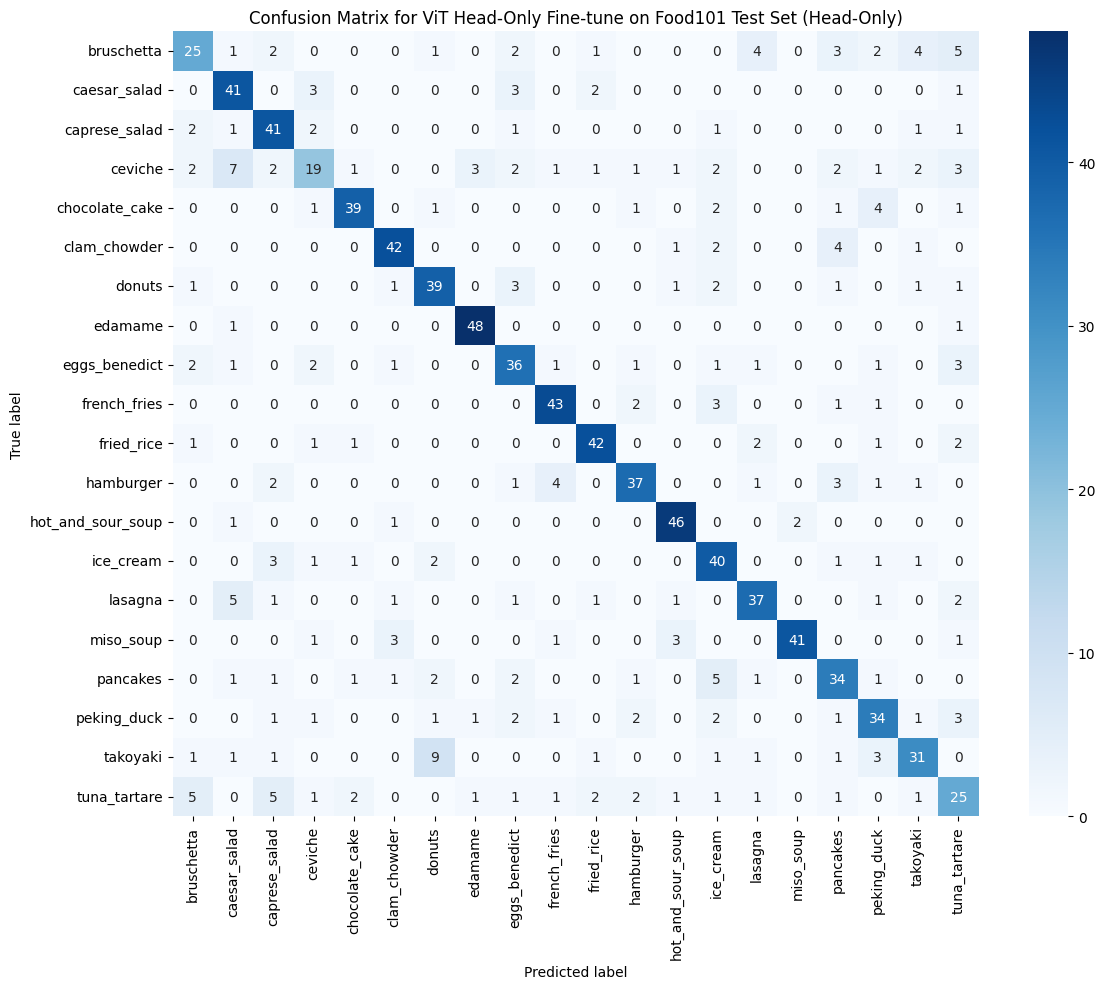


--- Per-class metrics for ViT Head-Only Fine-tune ---

Top 10 weakest classes by F1-score:


,precision,recall,f1-score,support
ceviche,0.5938,0.38,0.4634,50.0
tuna_tartare,0.5102,0.50,0.5051,50.0
bruschetta,0.6410,0.50,0.5618,50.0
takoyaki,0.7045,0.62,0.6596,50.0
pancakes,0.6415,0.68,0.6602,50.0
peking_duck,0.6667,0.68,0.6733,50.0
eggs_benedict,0.6667,0.72,0.6923,50.0
ice_cream,0.6452,0.80,0.7143,50.0
donuts,0.7091,0.78,0.7429,50.0
caesar_salad,0.6833,0.82,0.7455,50.0



Top 10 strongest classes by F1-score:


,precision,recall,f1-score,support
edamame,0.9057,0.96,0.9320,50.0
hot_and_sour_soup,0.8519,0.92,0.8846,50.0
miso_soup,0.9535,0.82,0.8817,50.0
french_fries,0.8269,0.86,0.8431,50.0
fried_rice,0.8400,0.84,0.8400,50.0
clam_chowder,0.8400,0.84,0.8400,50.0
chocolate_cake,0.8667,0.78,0.8211,50.0
hamburger,0.7872,0.74,0.7629,50.0
lasagna,0.7708,0.74,0.7551,50.0
caprese_salad,0.6949,0.82,0.7523,50.0


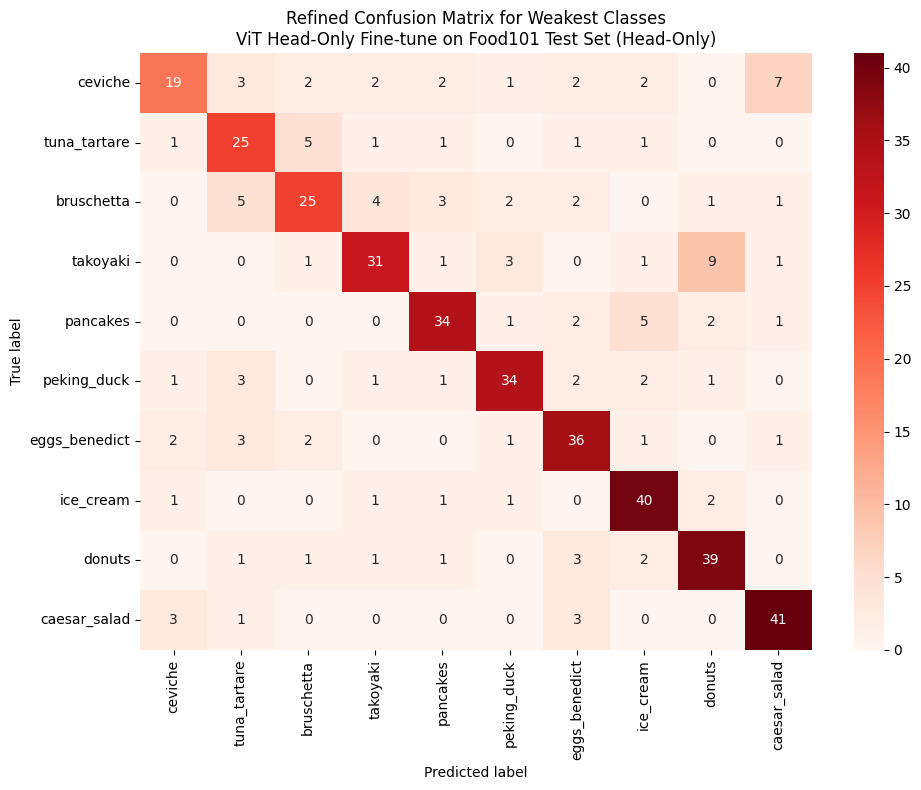

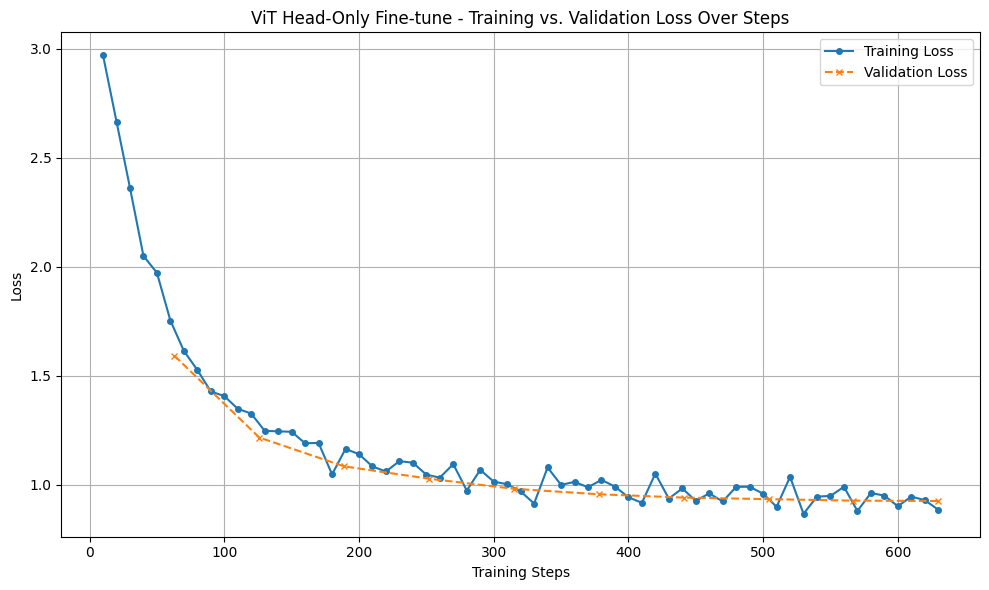

In [25]:
print("Trainable parameters for Head-Only Fine-tuning:")
count_parameters(model)

# Evaluate the head-only fine-tuned model on Food101 test set
head_only_metrics_food101 = evaluate_and_plot(
    model=model,
    trainer=trainer,
    dataset=food_vit["test"],
    id2label_mapping=id2label,
    dataset_name="Food101 Test Set (Head-Only)",
    num_labels=len(id2label),
    model_display_name="ViT Head-Only Fine-tune",
    training_time=vit_head_only_train_time
)

## Evaluate Full Model Fine-tuned Model

Using the `evaluate_and_plot` function to assess the performance of the full model fine-tuned model on the Food101 test set, including accuracy, F1-score, and a confusion matrix. This section also prints the number of trainable parameters for this stage.

Trainable parameters for Full Model Fine-tuning:
Number of trainable parameters: 5,528,276 (5.53 million)
Total parameters: 5,528,276 (5.53 million)

--- Evaluating ViT Full Fine-tune on Food101 Test Set (Full Fine-tune) ---



Core metrics:
Accuracy:                0.7930
Macro F1:                0.7929
Weighted F1:             0.7929
Top-5 Accuracy:          0.9570
Eval Loss:               0.7729

Confidence / calibration metrics:
Mean Top-1 Confidence:   0.6746
Mean Top1-Top2 Margin:   0.5650
Correct Mean Confidence: 0.7432
Wrong Mean Confidence:   0.4115
ECE:                     0.1184
NLL:                     0.7729
Brier Score:             0.3088

Training time for ViT Full Fine-tune: 422.54 seconds

Label sanity check:
Number of unique true labels:      20
Number of unique predicted labels: 20

Confidence summary:


top1_confidence                               top1_top2_margin  \
                   mean  median     min     max count             mean   
correct                                                                  
False            0.4115  0.3610  0.1222  0.8802   207           0.2211   
True             0.7432  0.7986  0.1323  0.9812   793           0.6548   

                                       
         median     min     max count  
correct                                
False    0.1494  0.0002  0.8577   207  
True     0.7366  0.0005  0.9791   793


Most confident wrong predictions:


,true_label_id,pred_label_id,true_label,pred_label,top1_confidence,top2_confidence,top1_top2_margin,correct
428,0,18,bruschetta,takoyaki,0.8802,0.0225,0.8577,False
588,10,14,fried_rice,lasagna,0.8695,0.0257,0.8438,False
798,3,19,ceviche,tuna_tartare,0.8099,0.0501,0.7599,False
82,18,16,takoyaki,pancakes,0.7780,0.0784,0.6995,False
67,11,17,hamburger,peking_duck,0.7772,0.0544,0.7228,False
123,18,6,takoyaki,donuts,0.7750,0.0737,0.7012,False
832,17,19,peking_duck,tuna_tartare,0.7746,0.0468,0.7278,False
53,3,1,ceviche,caesar_salad,0.7604,0.0600,0.7004,False
457,16,4,pancakes,chocolate_cake,0.7304,0.1597,0.5707,False
844,1,10,caesar_salad,fried_rice,0.7133,0.1330,0.5804,False



Lowest-margin predictions:


,true_label_id,pred_label_id,true_label,pred_label,top1_confidence,top2_confidence,top1_top2_margin,correct
829,16,13,pancakes,ice_cream,0.3583,0.3581,0.0002,False
742,10,0,fried_rice,bruschetta,0.2410,0.2406,0.0004,False
298,13,13,ice_cream,ice_cream,0.2520,0.2515,0.0005,True
521,18,14,takoyaki,lasagna,0.2318,0.2294,0.0024,False
962,5,5,clam_chowder,clam_chowder,0.2843,0.2818,0.0024,True
243,0,0,bruschetta,bruschetta,0.1323,0.1285,0.0037,True
698,19,19,tuna_tartare,tuna_tartare,0.2476,0.2438,0.0038,True
328,18,6,takoyaki,donuts,0.2203,0.2161,0.0042,False
415,15,5,miso_soup,clam_chowder,0.4686,0.4641,0.0045,False
124,19,1,tuna_tartare,caesar_salad,0.2143,0.2082,0.0061,False


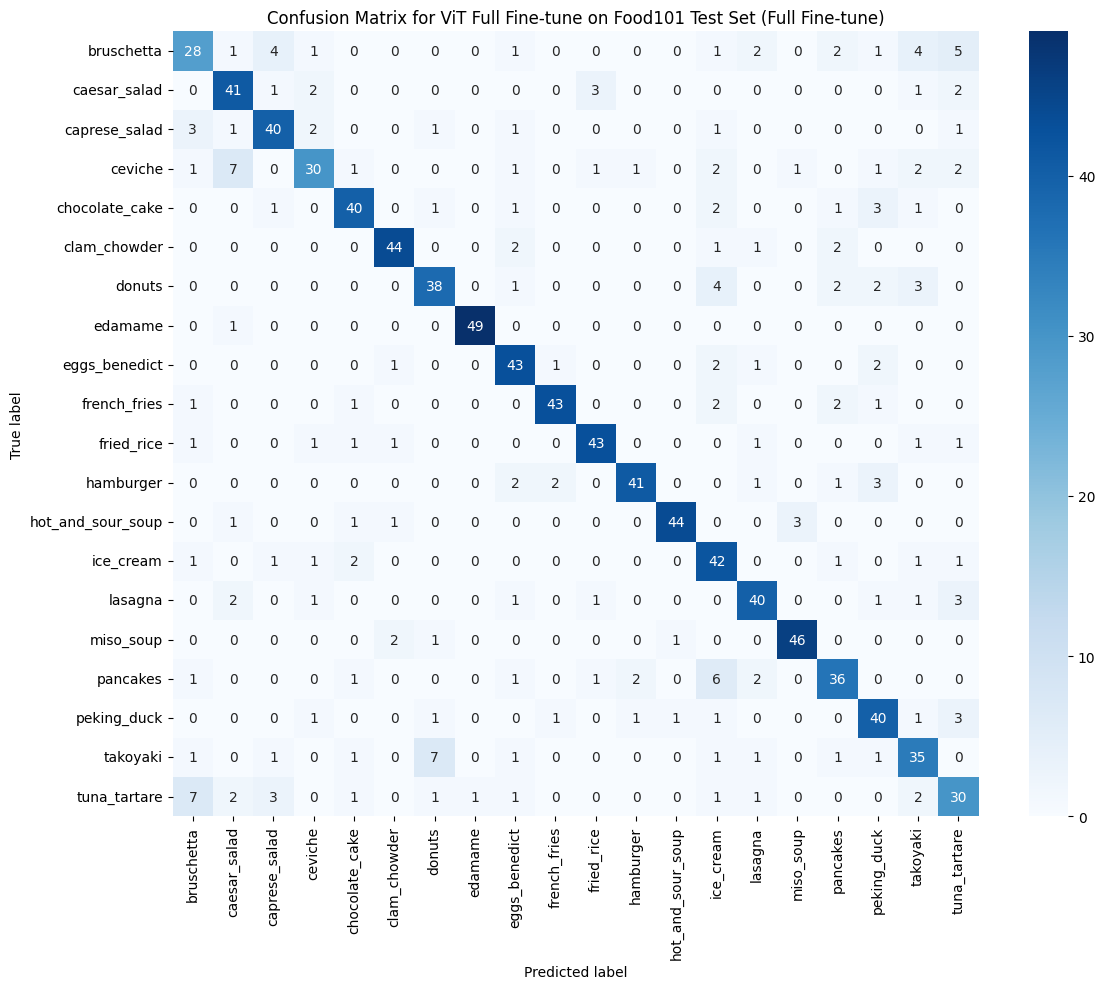


--- Per-class metrics for ViT Full Fine-tune ---

Top 10 weakest classes by F1-score:


,precision,recall,f1-score,support
bruschetta,0.6364,0.56,0.5957,50.0
tuna_tartare,0.6250,0.60,0.6122,50.0
ceviche,0.7692,0.60,0.6742,50.0
takoyaki,0.6731,0.70,0.6863,50.0
ice_cream,0.6364,0.84,0.7241,50.0
pancakes,0.7500,0.72,0.7347,50.0
donuts,0.7600,0.76,0.7600,50.0
peking_duck,0.7273,0.80,0.7619,50.0
caesar_salad,0.7321,0.82,0.7736,50.0
caprese_salad,0.7843,0.80,0.7921,50.0



Top 10 strongest classes by F1-score:


,precision,recall,f1-score,support
edamame,0.9800,0.98,0.9800,50.0
miso_soup,0.9200,0.92,0.9200,50.0
hot_and_sour_soup,0.9565,0.88,0.9167,50.0
clam_chowder,0.8980,0.88,0.8889,50.0
french_fries,0.9149,0.86,0.8866,50.0
fried_rice,0.8776,0.86,0.8687,50.0
hamburger,0.9111,0.82,0.8632,50.0
eggs_benedict,0.7679,0.86,0.8113,50.0
chocolate_cake,0.8163,0.80,0.8081,50.0
lasagna,0.8000,0.80,0.8000,50.0


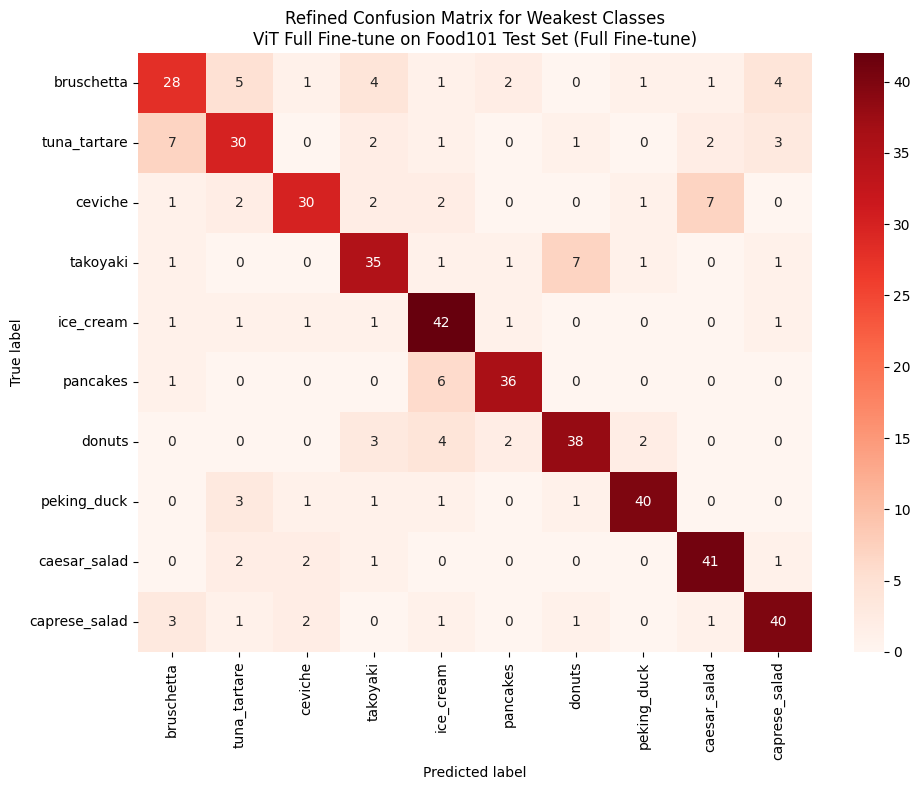

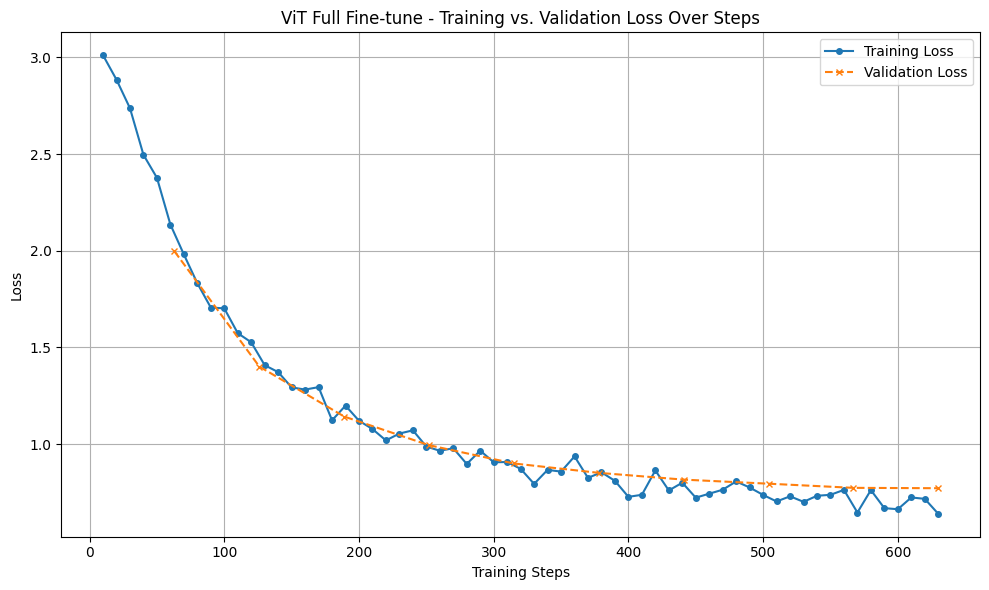

In [26]:
print("Trainable parameters for Full Model Fine-tuning:")
count_parameters(model_full_finetune)

# Evaluate the full model fine-tuned model on Food101 test set
full_finetune_metrics_food101 = evaluate_and_plot(
    model=model_full_finetune,
    trainer=trainer_full,
    dataset=food_vit["test"],
    id2label_mapping=id2label,
    dataset_name="Food101 Test Set (Full Fine-tune)",
    num_labels=len(id2label),
    model_display_name="ViT Full Fine-tune",
    training_time=vit_full_train_time
)

## Evaluate LoRA Fine-tuned Model

Using the `evaluate_and_plot` function to assess the performance of the LoRA fine-tuned model on the Food101 test set, including accuracy, F1-score, and a confusion matrix. This section also prints the number of trainable parameters for this stage.

Trainable parameters for LoRA Fine-tuning:
trainable params: 77,588 || all params: 5,605,864 || trainable%: 1.3841

--- Evaluating ViT LoRA Fine-tune on Food101 Test Set (LoRA) ---



Core metrics:
Accuracy:                0.7540
Macro F1:                0.7506
Weighted F1:             0.7506
Top-5 Accuracy:          0.9510
Eval Loss:               0.8922

Confidence / calibration metrics:
Mean Top-1 Confidence:   0.6289
Mean Top1-Top2 Margin:   0.4946
Correct Mean Confidence: 0.6995
Wrong Mean Confidence:   0.4125
ECE:                     0.1274
NLL:                     0.8922
Brier Score:             0.3685

Training time for ViT LoRA Fine-tune: 370.18 seconds

Label sanity check:
Number of unique true labels:      20
Number of unique predicted labels: 20

Confidence summary:


top1_confidence                               top1_top2_margin  \
                   mean  median     min     max count             mean   
correct                                                                  
False            0.4125  0.3786  0.1505  0.8792   246           0.2150   
True             0.6995  0.7365  0.1617  0.9874   754           0.5858   

                                       
         median     min     max count  
correct                                
False    0.1515  0.0013  0.8482   246  
True     0.6229  0.0011  0.9827   754


Most confident wrong predictions:


,true_label_id,pred_label_id,true_label,pred_label,top1_confidence,top2_confidence,top1_top2_margin,correct
768,0,19,bruschetta,tuna_tartare,0.8792,0.0310,0.8482,False
408,0,14,bruschetta,lasagna,0.8310,0.0404,0.7906,False
415,15,5,miso_soup,clam_chowder,0.7915,0.1679,0.6235,False
392,11,9,hamburger,french_fries,0.7898,0.1499,0.6399,False
373,11,9,hamburger,french_fries,0.7806,0.1554,0.6251,False
588,10,14,fried_rice,lasagna,0.7791,0.0705,0.7086,False
390,9,17,french_fries,peking_duck,0.7687,0.0711,0.6976,False
446,18,6,takoyaki,donuts,0.7608,0.0756,0.6852,False
710,4,6,chocolate_cake,donuts,0.7434,0.0959,0.6475,False
123,18,6,takoyaki,donuts,0.7410,0.0656,0.6754,False



Lowest-margin predictions:


,true_label_id,pred_label_id,true_label,pred_label,top1_confidence,top2_confidence,top1_top2_margin,correct
869,3,3,ceviche,ceviche,0.2587,0.2575,0.0011,True
201,3,3,ceviche,ceviche,0.3229,0.3218,0.0011,True
813,18,1,takoyaki,caesar_salad,0.2234,0.2222,0.0013,False
698,19,2,tuna_tartare,caprese_salad,0.3019,0.3005,0.0014,False
619,8,11,eggs_benedict,hamburger,0.3951,0.3936,0.0015,False
247,11,16,hamburger,pancakes,0.3829,0.3813,0.0015,False
973,15,15,miso_soup,miso_soup,0.4367,0.4350,0.0017,True
532,0,0,bruschetta,bruschetta,0.3831,0.3812,0.0019,True
526,9,8,french_fries,eggs_benedict,0.2737,0.2713,0.0024,False
341,8,1,eggs_benedict,caesar_salad,0.2219,0.2190,0.0028,False


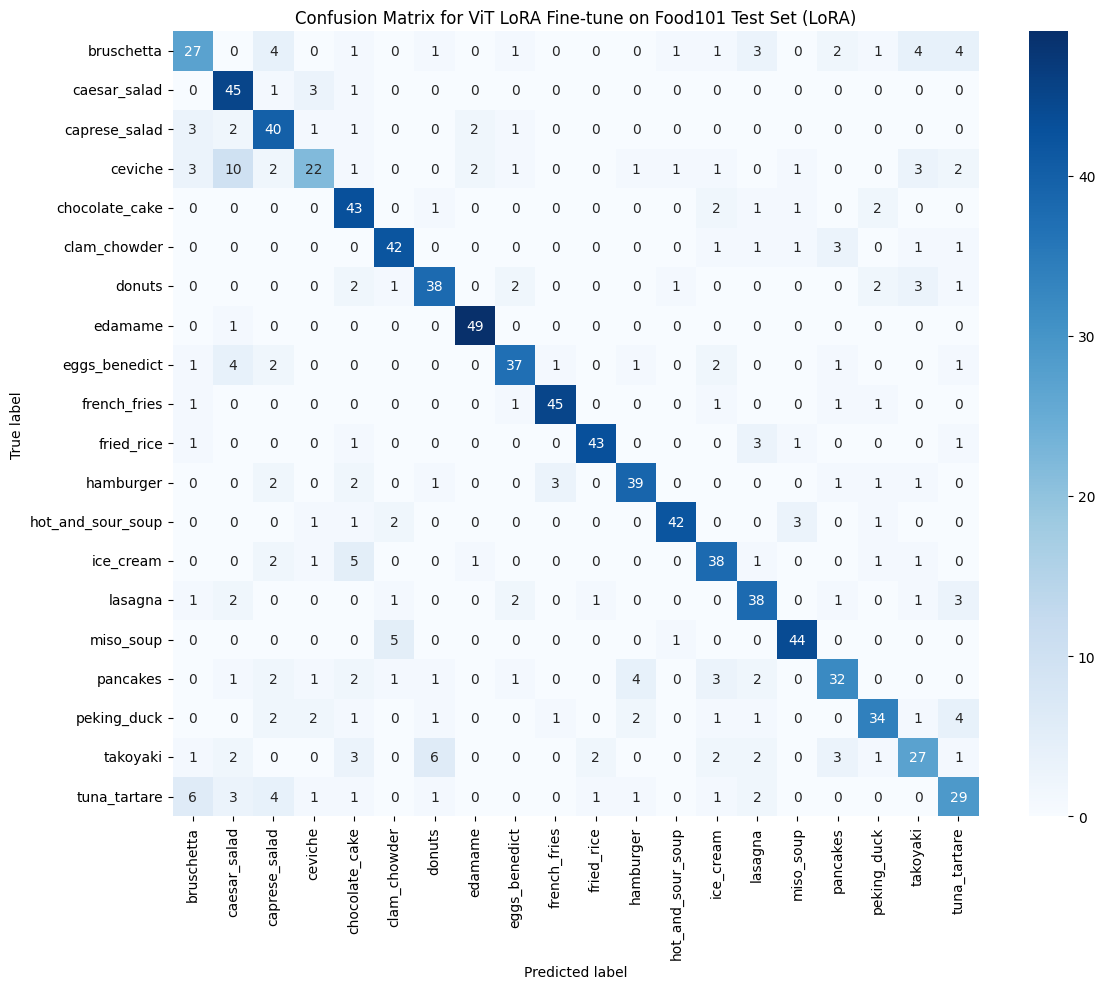


--- Per-class metrics for ViT LoRA Fine-tune ---

Top 10 weakest classes by F1-score:


,precision,recall,f1-score,support
ceviche,0.6875,0.44,0.5366,50.0
bruschetta,0.6136,0.54,0.5745,50.0
takoyaki,0.6429,0.54,0.5870,50.0
tuna_tartare,0.6170,0.58,0.5979,50.0
pancakes,0.7273,0.64,0.6809,50.0
caprese_salad,0.6557,0.80,0.7207,50.0
peking_duck,0.7727,0.68,0.7234,50.0
lasagna,0.7037,0.76,0.7308,50.0
ice_cream,0.7170,0.76,0.7379,50.0
chocolate_cake,0.6615,0.86,0.7478,50.0



Top 10 strongest classes by F1-score:


,precision,recall,f1-score,support
edamame,0.9074,0.98,0.9423,50.0
french_fries,0.9000,0.90,0.9000,50.0
fried_rice,0.9149,0.86,0.8866,50.0
hot_and_sour_soup,0.9130,0.84,0.8750,50.0
miso_soup,0.8627,0.88,0.8713,50.0
clam_chowder,0.8077,0.84,0.8235,50.0
hamburger,0.8125,0.78,0.7959,50.0
eggs_benedict,0.8043,0.74,0.7708,50.0
donuts,0.7600,0.76,0.7600,50.0
caesar_salad,0.6429,0.90,0.7500,50.0


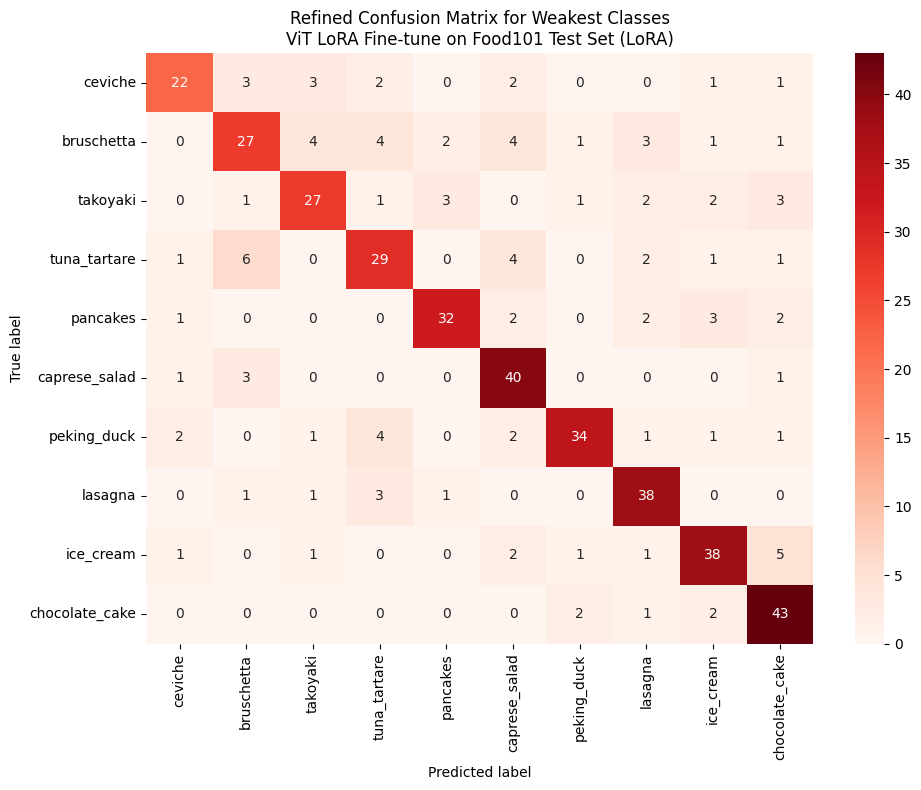

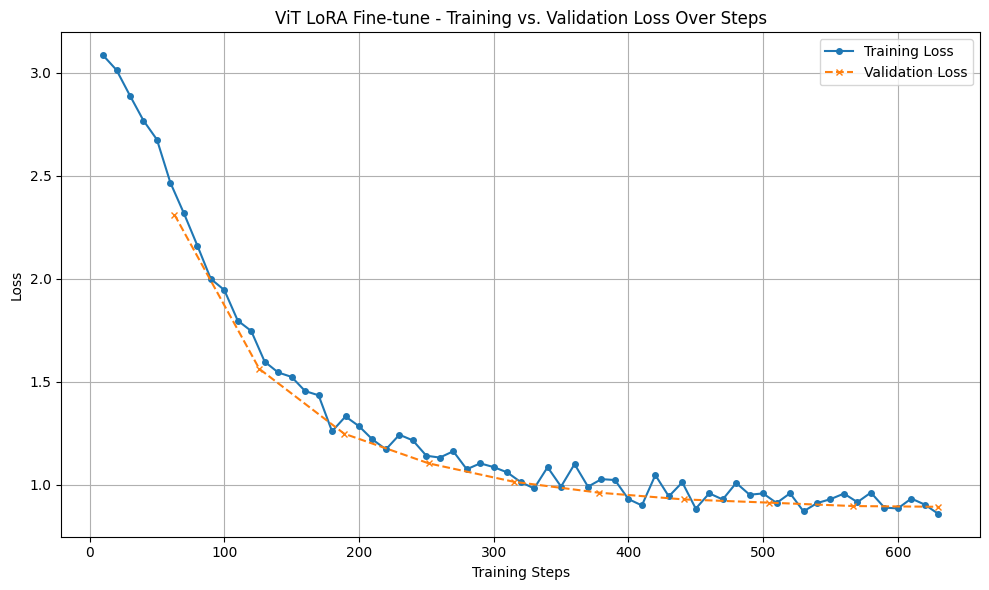

In [27]:
print("Trainable parameters for LoRA Fine-tuning:")
model_lora.print_trainable_parameters() # LoRA models have their own method for this

# Evaluate the LoRA fine-tuned model on Food101 test set
lora_metrics_food101 = evaluate_and_plot(
    model=model_lora,
    trainer=trainer_lora,
    dataset=food_vit["test"],
    id2label_mapping=id2label,
    dataset_name="Food101 Test Set (LoRA)",
    num_labels=len(id2label),
    model_display_name="ViT LoRA Fine-tune",
    training_time=vit_lora_train_time
)

## Fine-tuning Last 3 Encoder Blocks + Head

This section will fine-tune the classification head along with the last 3 encoder blocks of the ViT backbone on the Food101 dataset.

In [29]:
# Re-initialize the model and freeze all layers initially
model_last_3_blocks = AutoModelForImageClassification.from_pretrained(
    checkpoint,
    num_labels=len(labels),
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
)

# Freeze all layers
for param in model_last_3_blocks.parameters():
    param.requires_grad = False

# Unfreeze the classification head
for param in model_last_3_blocks.classifier.parameters():
    param.requires_grad = True

# Unfreeze the last 3 encoder layers
num_encoder_layers = len(model_last_3_blocks.vit.layers)
for i in range(num_encoder_layers - 3, num_encoder_layers):
    for param in model_last_3_blocks.vit.layers[i].parameters():
        param.requires_grad = True

print("Model re-initialized. Last 3 encoder blocks and head are unfrozen for fine-tuning.")
count_parameters(model_last_3_blocks)

[transformers] You passed `num_labels=20` which is incompatible to the `id2label` map of length `1000`.


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

[transformers] ViTForImageClassification LOAD REPORT from: facebook/deit-tiny-patch16-224
Key               | Status   |                                                                                           
------------------+----------+-------------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([20])          
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 192]) vs model:torch.Size([20, 192])

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


Model re-initialized. Last 3 encoder blocks and head are unfrozen for fine-tuning.
Number of trainable parameters: 1,338,452 (1.34 million)
Total parameters: 5,528,276 (5.53 million)


### Train the Model (Last 3 Blocks + Head)

In [30]:
training_args_last_3_blocks = TrainingArguments(
    output_dir="/content/drive/MyDrive/ViTExperiments/food101_20cls_250_last_3_blocks",
    remove_unused_columns=False,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=1e-4,
    per_device_train_batch_size=16,
    gradient_accumulation_steps=4,
    per_device_eval_batch_size=16,
    num_train_epochs=10,
    warmup_steps=10,
    logging_steps=10,
    run_name="food101_last_3_blocks",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    push_to_hub=False,
)

trainer_last_3_blocks = Trainer(
    model=model_last_3_blocks,
    args=training_args_last_3_blocks,
    data_collator=data_collator,
    train_dataset=food_vit["train"],
    eval_dataset=food_vit["test"],
    processing_class=image_processor,
    compute_metrics=compute_metrics,
)

print("Starting fine-tuning for last 3 blocks + head...")
vit_last_3_blocks_train_time = conditional_train_model(model_last_3_blocks, trainer_last_3_blocks, training_args_last_3_blocks, "ViT Last 3 Blocks + Head Fine-tune")
print("Fine-tuning for last 3 blocks + head complete.")


Starting fine-tuning for last 3 blocks + head...

--- Conditional training check for ViT Last 3 Blocks + Head Fine-tune ---
Output directory: /content/drive/MyDrive/ViTExperiments/food101_20cls_250_last_3_blocks
FORCE_FINE_TUNING: True
Final model exists at root: False
Latest checkpoint: None
Latest checkpoint has weights: False
Starting fresh fine-tuning for ViT Last 3 Blocks + Head Fine-tune.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1,F1,Top 5 Accuracy,Mean Top1 Confidence,Mean Top1 Top2 Margin,Correct Mean Confidence,Wrong Mean Confidence,Ece,Nll,Brier Score
1,1.733962,1.510580,0.637000,0.628229,0.628229,0.628229,0.910000,0.339317,0.200506,0.404120,0.225601,0.297880,1.510580,0.603305
2,1.217238,1.053156,0.740000,0.736267,0.736267,0.736267,0.946000,0.541023,0.410769,0.605326,0.358005,0.198977,1.053156,0.425349
3,0.850903,0.889441,0.766000,0.766244,0.766244,0.766244,0.956000,0.627998,0.503266,0.692800,0.415868,0.139895,0.889441,0.360882
4,0.832669,0.791018,0.790000,0.790457,0.790457,0.790457,0.957000,0.677092,0.564789,0.741914,0.433236,0.112908,0.791018,0.318060
5,0.745610,0.747075,0.799000,0.799866,0.799866,0.799866,0.960000,0.710373,0.606551,0.771422,0.467694,0.090612,0.747075,0.302000
6,0.720685,0.712174,0.810000,0.810219,0.810219,0.810219,0.962000,0.730780,0.632695,0.789681,0.479676,0.079220,0.712174,0.286827
7,0.681769,0.677929,0.825000,0.825583,0.825583,0.825583,0.961000,0.742673,0.645741,0.797013,0.486496,0.082327,0.677929,0.272125
8,0.622655,0.666527,0.812000,0.812998,0.812998,0.812998,0.961000,0.749910,0.655086,0.813504,0.475237,0.066759,0.666527,0.268346
9,0.666307,0.653587,0.826000,0.826265,0.826265,0.826265,0.961000,0.757599,0.665982,0.813354,0.492922,0.070892,0.653587,0.262824
10,0.535587,0.653010,0.817000,0.817028,0.817028,0.817028,0.961000,0.758901,0.667850,0.821107,0.481182,0.061870,0.653010,0.262444


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['vit.layers.0.attention.q_proj.weight', 'vit.layers.0.attention.q_proj.bias', 'vit.layers.0.attention.k_proj.weight', 'vit.layers.0.attention.k_proj.bias', 'vit.layers.0.attention.v_proj.weight', 'vit.layers.0.attention.v_proj.bias', 'vit.layers.0.attention.o_proj.weight', 'vit.layers.0.attention.o_proj.bias', 'vit.layers.0.layernorm_before.weight', 'vit.layers.0.layernorm_before.bias', 'vit.layers.0.layernorm_after.weight', 'vit.layers.0.layernorm_after.bias', 'vit.layers.0.mlp.fc1.weight', 'vit.layers.0.mlp.fc1.bias', 'vit.layers.0.mlp.fc2.weight', 'vit.layers.0.mlp.fc2.bias', 'vit.layers.1.attention.q_proj.weight', 'vit.layers.1.attention.q_proj.bias', 'vit.layers.1.attention.k_proj.weight', 'vit.layers.1.attention.k_proj.bias', 'vit.layers.1.attention.v_proj.weight', 'vit.layers.1.attention.v_proj.bias', 'vit.layers.1.attention.o_proj.weight', 'vit.layers.1.attention.o_proj.bias', 'vit.layers.1.layernorm_before

Training complete for ViT Last 3 Blocks + Head Fine-tune.
Train runtime: 324.65 seconds
Saving final model for ViT Last 3 Blocks + Head Fine-tune to: /content/drive/MyDrive/ViTExperiments/food101_20cls_250_last_3_blocks


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved train metrics to: /content/drive/MyDrive/ViTExperiments/food101_20cls_250_last_3_blocks/train_metrics.json
Fine-tuning for last 3 blocks + head complete.


### Evaluate Model (Last 3 Blocks + Head)

Trainable parameters for Last 3 Blocks + Head Fine-tuning:
Number of trainable parameters: 1,338,452 (1.34 million)
Total parameters: 5,528,276 (5.53 million)

--- Evaluating ViT Last 3 Blocks + Head Fine-tune on Food101 Test Set (Last 3 Blocks + Head) ---



Core metrics:
Accuracy:                0.8160
Macro F1:                0.8158
Weighted F1:             0.8158
Top-5 Accuracy:          0.9610
Eval Loss:               0.6534

Confidence / calibration metrics:
Mean Top-1 Confidence:   0.7582
Mean Top1-Top2 Margin:   0.6671
Correct Mean Confidence: 0.8211
Wrong Mean Confidence:   0.4794
ECE:                     0.0616
NLL:                     0.6534
Brier Score:             0.2625

Training time for ViT Last 3 Blocks + Head Fine-tune: 324.65 seconds

Label sanity check:
Number of unique true labels:      20
Number of unique predicted labels: 20

Confidence summary:


top1_confidence                               top1_top2_margin  \
                   mean  median     min     max count             mean   
correct                                                                  
False            0.4794  0.4512  0.1321  0.9275   184           0.2890   
True             0.8211  0.9008  0.2023  0.9893   816           0.7523   

                                       
         median     min     max count  
correct                                
False    0.2163  0.0002  0.8824   184  
True     0.8617  0.0118  0.9880   816


Most confident wrong predictions:


,true_label_id,pred_label_id,true_label,pred_label,top1_confidence,top2_confidence,top1_top2_margin,correct
373,11,9,hamburger,french_fries,0.9275,0.0453,0.8822,False
588,10,14,fried_rice,lasagna,0.9065,0.0241,0.8824,False
408,0,14,bruschetta,lasagna,0.9057,0.0252,0.8805,False
148,15,5,miso_soup,clam_chowder,0.9015,0.0683,0.8331,False
898,13,3,ice_cream,ceviche,0.8935,0.0141,0.8794,False
399,3,1,ceviche,caesar_salad,0.8870,0.0305,0.8565,False
917,2,0,caprese_salad,bruschetta,0.8791,0.0538,0.8254,False
863,8,9,eggs_benedict,french_fries,0.8775,0.0589,0.8186,False
845,1,3,caesar_salad,ceviche,0.8756,0.0298,0.8458,False
798,3,19,ceviche,tuna_tartare,0.8702,0.0389,0.8313,False



Lowest-margin predictions:


,true_label_id,pred_label_id,true_label,pred_label,top1_confidence,top2_confidence,top1_top2_margin,correct
55,3,12,ceviche,hot_and_sour_soup,0.3081,0.3080,0.0002,False
111,13,14,ice_cream,lasagna,0.2537,0.2533,0.0004,False
50,3,12,ceviche,hot_and_sour_soup,0.2664,0.2614,0.0051,False
406,11,2,hamburger,caprese_salad,0.4169,0.4116,0.0054,False
245,14,18,lasagna,takoyaki,0.1793,0.1680,0.0114,False
848,6,16,donuts,pancakes,0.1321,0.1205,0.0116,False
560,3,3,ceviche,ceviche,0.2051,0.1933,0.0118,True
949,3,17,ceviche,peking_duck,0.1846,0.1707,0.0139,False
505,3,19,ceviche,tuna_tartare,0.1534,0.1386,0.0147,False
89,3,0,ceviche,bruschetta,0.3463,0.3314,0.0149,False


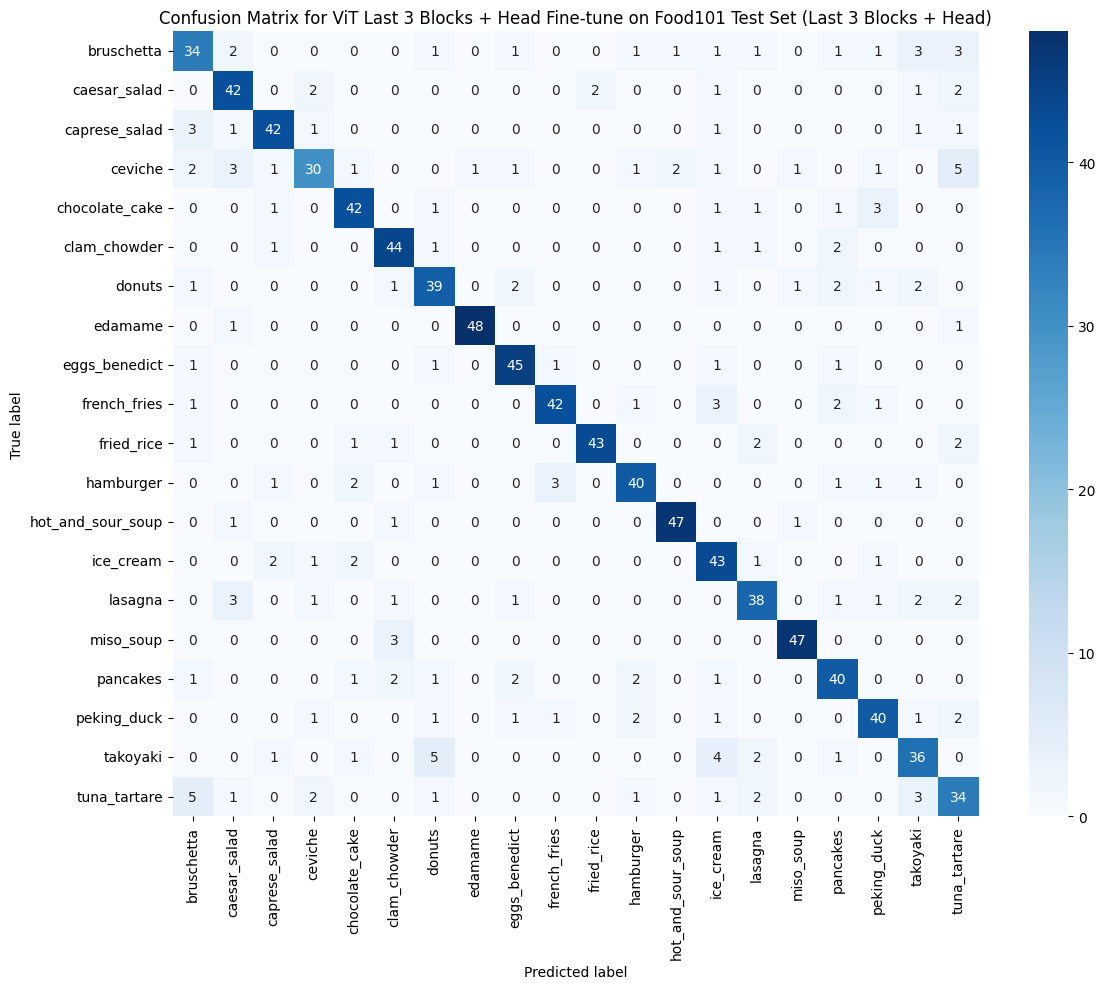


--- Per-class metrics for ViT Last 3 Blocks + Head Fine-tune ---

Top 10 weakest classes by F1-score:


,precision,recall,f1-score,support
tuna_tartare,0.6538,0.68,0.6667,50.0
ceviche,0.7895,0.60,0.6818,50.0
bruschetta,0.6939,0.68,0.6869,50.0
takoyaki,0.7200,0.72,0.7200,50.0
donuts,0.7500,0.78,0.7647,50.0
ice_cream,0.7049,0.86,0.7748,50.0
lasagna,0.7917,0.76,0.7755,50.0
pancakes,0.7692,0.80,0.7843,50.0
peking_duck,0.8000,0.80,0.8000,50.0
caesar_salad,0.7778,0.84,0.8077,50.0



Top 10 strongest classes by F1-score:


,precision,recall,f1-score,support
edamame,0.9796,0.96,0.9697,50.0
hot_and_sour_soup,0.9400,0.94,0.9400,50.0
miso_soup,0.9400,0.94,0.9400,50.0
fried_rice,0.9556,0.86,0.9053,50.0
eggs_benedict,0.8491,0.90,0.8738,50.0
french_fries,0.8936,0.84,0.8660,50.0
clam_chowder,0.8302,0.88,0.8544,50.0
caprese_salad,0.8571,0.84,0.8485,50.0
chocolate_cake,0.8400,0.84,0.8400,50.0
hamburger,0.8333,0.80,0.8163,50.0


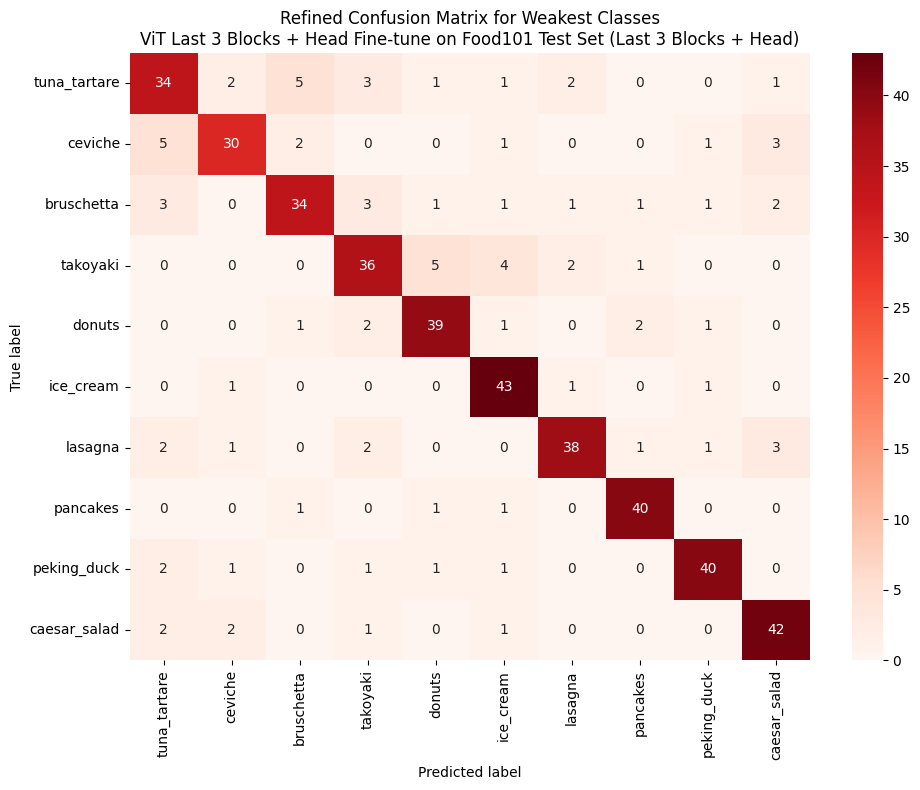

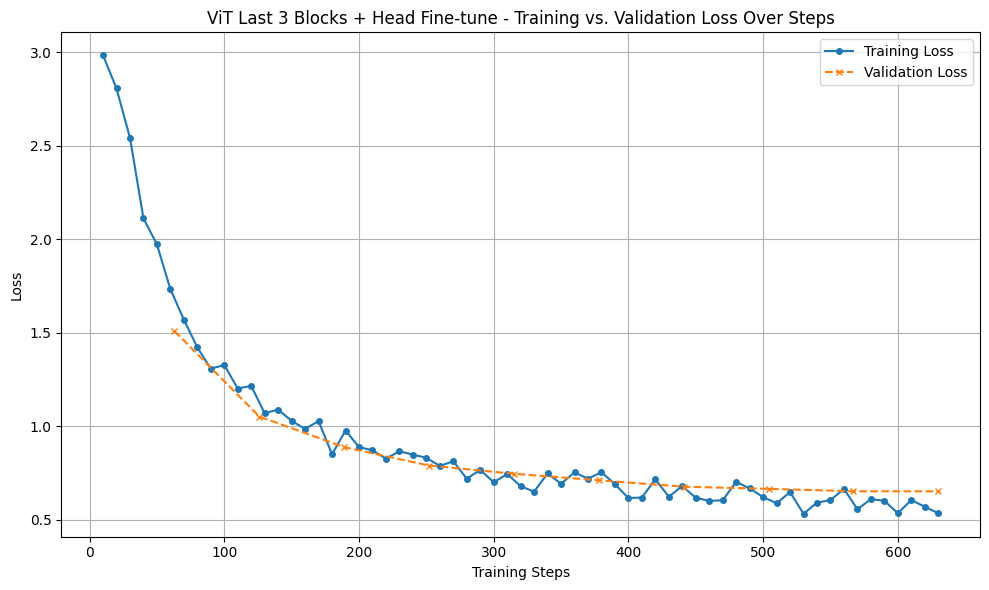

In [31]:
print("Trainable parameters for Last 3 Blocks + Head Fine-tuning:")
count_parameters(model_last_3_blocks)

last_3_blocks_metrics_food101 = evaluate_and_plot(
    model=model_last_3_blocks,
    trainer=trainer_last_3_blocks,
    dataset=food_vit["test"],
    id2label_mapping=id2label,
    dataset_name="Food101 Test Set (Last 3 Blocks + Head)",
    num_labels=len(id2label),
    model_display_name="ViT Last 3 Blocks + Head Fine-tune",
    training_time=vit_last_3_blocks_train_time
)

## Fine-tuning Last 5 Encoder Blocks + Head

This section will fine-tune the classification head along with the last 5 encoder blocks of the ViT backbone on the Food101 dataset.

In [33]:
# Re-initialize the model and freeze all layers initially
model_last_5_blocks = AutoModelForImageClassification.from_pretrained(
    checkpoint,
    num_labels=len(labels),
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
)

# Freeze all layers
for param in model_last_5_blocks.parameters():
    param.requires_grad = False

# Unfreeze the classification head
for param in model_last_5_blocks.classifier.parameters():
    param.requires_grad = True

# Unfreeze the last 5 encoder layers
num_encoder_layers = len(model_last_5_blocks.vit.layers)
for i in range(num_encoder_layers - 5, num_encoder_layers):
    for param in model_last_5_blocks.vit.layers[i].parameters():
        param.requires_grad = True

print("Model re-initialized. Last 5 encoder blocks and head are unfrozen for fine-tuning.")
count_parameters(model_last_5_blocks)

[transformers] You passed `num_labels=20` which is incompatible to the `id2label` map of length `1000`.


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

[transformers] ViTForImageClassification LOAD REPORT from: facebook/deit-tiny-patch16-224
Key               | Status   |                                                                                           
------------------+----------+-------------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([20])          
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 192]) vs model:torch.Size([20, 192])

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


Model re-initialized. Last 5 encoder blocks and head are unfrozen for fine-tuning.
Number of trainable parameters: 2,228,180 (2.23 million)
Total parameters: 5,528,276 (5.53 million)


### Train the Model (Last 5 Blocks + Head)

In [34]:
training_args_last_5_blocks = TrainingArguments(
    output_dir="/content/drive/MyDrive/ViTExperiments/food101_20cls_250_last_5_blocks",
    remove_unused_columns=False,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=1e-4,
    per_device_train_batch_size=16,
    gradient_accumulation_steps=4,
    per_device_eval_batch_size=16,
    num_train_epochs=10,
    warmup_steps=10,
    logging_steps=10,
    run_name="food101_last_5_blocks",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    push_to_hub=False,
)

trainer_last_5_blocks = Trainer(
    model=model_last_5_blocks,
    args=training_args_last_5_blocks,
    data_collator=data_collator,
    train_dataset=food_vit["train"],
    eval_dataset=food_vit["test"],
    processing_class=image_processor,
    compute_metrics=compute_metrics,
)

print("Starting fine-tuning for last 5 blocks + head...")
vit_last_5_blocks_train_time = conditional_train_model(model_last_5_blocks, trainer_last_5_blocks, training_args_last_5_blocks, "ViT Last 5 Blocks + Head Fine-tune")
print("Fine-tuning for last 5 blocks + head complete.")


Starting fine-tuning for last 5 blocks + head...

--- Conditional training check for ViT Last 5 Blocks + Head Fine-tune ---
Output directory: /content/drive/MyDrive/ViTExperiments/food101_20cls_250_last_5_blocks
FORCE_FINE_TUNING: True
Final model exists at root: False
Latest checkpoint: None
Latest checkpoint has weights: False
Starting fresh fine-tuning for ViT Last 5 Blocks + Head Fine-tune.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1,F1,Top 5 Accuracy,Mean Top1 Confidence,Mean Top1 Top2 Margin,Correct Mean Confidence,Wrong Mean Confidence,Ece,Nll,Brier Score
1,1.473225,1.300975,0.688000,0.682834,0.682834,0.682834,0.921000,0.414205,0.278513,0.482943,0.262631,0.273795,1.300975,0.521008
2,1.008502,0.880071,0.769000,0.766929,0.766929,0.766929,0.954000,0.622724,0.509467,0.692860,0.389243,0.148684,0.880071,0.349970
3,0.688649,0.746430,0.799000,0.798229,0.798229,0.798229,0.958000,0.703415,0.603609,0.768972,0.442821,0.097065,0.746430,0.294962
4,0.659777,0.679502,0.815000,0.815489,0.815489,0.815489,0.963000,0.738715,0.645333,0.801148,0.463674,0.079481,0.679502,0.270174
5,0.606314,0.641951,0.821000,0.821981,0.821981,0.821981,0.972000,0.768868,0.684952,0.829305,0.491667,0.060467,0.641951,0.257547
6,0.556577,0.622830,0.811000,0.810754,0.810754,0.810754,0.966000,0.783825,0.704644,0.851802,0.492135,0.054949,0.622830,0.251745
7,0.541411,0.595176,0.826000,0.825913,0.825913,0.825913,0.966000,0.794260,0.714158,0.854714,0.507278,0.045814,0.595176,0.242248
8,0.509495,0.578003,0.828000,0.828265,0.828265,0.828265,0.970000,0.803338,0.727832,0.864296,0.509888,0.042324,0.578003,0.235678
9,0.501933,0.578487,0.827000,0.826810,0.826810,0.826810,0.971000,0.808152,0.735052,0.868369,0.520296,0.041924,0.578487,0.236906
10,0.387317,0.570252,0.833000,0.833012,0.833012,0.833012,0.970000,0.810774,0.737687,0.869162,0.519534,0.034452,0.570252,0.233241


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['vit.layers.0.attention.q_proj.weight', 'vit.layers.0.attention.q_proj.bias', 'vit.layers.0.attention.k_proj.weight', 'vit.layers.0.attention.k_proj.bias', 'vit.layers.0.attention.v_proj.weight', 'vit.layers.0.attention.v_proj.bias', 'vit.layers.0.attention.o_proj.weight', 'vit.layers.0.attention.o_proj.bias', 'vit.layers.0.layernorm_before.weight', 'vit.layers.0.layernorm_before.bias', 'vit.layers.0.layernorm_after.weight', 'vit.layers.0.layernorm_after.bias', 'vit.layers.0.mlp.fc1.weight', 'vit.layers.0.mlp.fc1.bias', 'vit.layers.0.mlp.fc2.weight', 'vit.layers.0.mlp.fc2.bias', 'vit.layers.1.attention.q_proj.weight', 'vit.layers.1.attention.q_proj.bias', 'vit.layers.1.attention.k_proj.weight', 'vit.layers.1.attention.k_proj.bias', 'vit.layers.1.attention.v_proj.weight', 'vit.layers.1.attention.v_proj.bias', 'vit.layers.1.attention.o_proj.weight', 'vit.layers.1.attention.o_proj.bias', 'vit.layers.1.layernorm_before

Training complete for ViT Last 5 Blocks + Head Fine-tune.
Train runtime: 333.50 seconds
Saving final model for ViT Last 5 Blocks + Head Fine-tune to: /content/drive/MyDrive/ViTExperiments/food101_20cls_250_last_5_blocks


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved train metrics to: /content/drive/MyDrive/ViTExperiments/food101_20cls_250_last_5_blocks/train_metrics.json
Fine-tuning for last 5 blocks + head complete.


### Evaluate Model (Last 5 Blocks + Head)

Trainable parameters for Last 5 Blocks + Head Fine-tuning:
Number of trainable parameters: 2,228,180 (2.23 million)
Total parameters: 5,528,276 (5.53 million)

--- Evaluating ViT Last 5 Blocks + Head Fine-tune on Food101 Test Set (Last 5 Blocks + Head) ---



Core metrics:
Accuracy:                0.8330
Macro F1:                0.8330
Weighted F1:             0.8330
Top-5 Accuracy:          0.9700
Eval Loss:               0.5703

Confidence / calibration metrics:
Mean Top-1 Confidence:   0.8108
Mean Top1-Top2 Margin:   0.7377
Correct Mean Confidence: 0.8692
Wrong Mean Confidence:   0.5195
ECE:                     0.0345
NLL:                     0.5703
Brier Score:             0.2332

Training time for ViT Last 5 Blocks + Head Fine-tune: 333.50 seconds

Label sanity check:
Number of unique true labels:      20
Number of unique predicted labels: 20

Confidence summary:


top1_confidence                               top1_top2_margin  \
                   mean  median     min     max count             mean   
correct                                                                  
False            0.5195  0.4979  0.2059  0.9386   167           0.3439   
True             0.8692  0.9390  0.1796  0.9923   833           0.8166   

                                      
         median    min     max count  
correct                               
False    0.3100  0.004  0.9170   167  
True     0.9218  0.014  0.9909   833


Most confident wrong predictions:


,true_label_id,pred_label_id,true_label,pred_label,top1_confidence,top2_confidence,top1_top2_margin,correct
798,3,19,ceviche,tuna_tartare,0.9386,0.0216,0.9170,False
838,16,11,pancakes,hamburger,0.9215,0.0125,0.9090,False
957,12,15,hot_and_sour_soup,miso_soup,0.9114,0.0550,0.8564,False
574,14,1,lasagna,caesar_salad,0.9059,0.0448,0.8611,False
67,11,17,hamburger,peking_duck,0.9011,0.0190,0.8821,False
24,4,17,chocolate_cake,peking_duck,0.8912,0.0330,0.8583,False
863,8,9,eggs_benedict,french_fries,0.8890,0.0709,0.8180,False
241,0,18,bruschetta,takoyaki,0.8739,0.0295,0.8445,False
897,11,4,hamburger,chocolate_cake,0.8666,0.0308,0.8357,False
588,10,14,fried_rice,lasagna,0.8582,0.0435,0.8147,False



Lowest-margin predictions:


,true_label_id,pred_label_id,true_label,pred_label,top1_confidence,top2_confidence,top1_top2_margin,correct
851,19,11,tuna_tartare,hamburger,0.2059,0.2020,0.0040,False
152,5,8,clam_chowder,eggs_benedict,0.2161,0.2081,0.0080,False
21,6,17,donuts,peking_duck,0.2558,0.2464,0.0093,False
375,0,0,bruschetta,bruschetta,0.2170,0.2030,0.0140,True
54,2,7,caprese_salad,edamame,0.3357,0.3187,0.0170,False
536,16,13,pancakes,ice_cream,0.2900,0.2718,0.0182,False
452,18,2,takoyaki,caprese_salad,0.2102,0.1880,0.0222,False
626,6,6,donuts,donuts,0.1796,0.1567,0.0228,True
184,19,11,tuna_tartare,hamburger,0.2297,0.2057,0.0240,False
660,15,15,miso_soup,miso_soup,0.4781,0.4515,0.0265,True


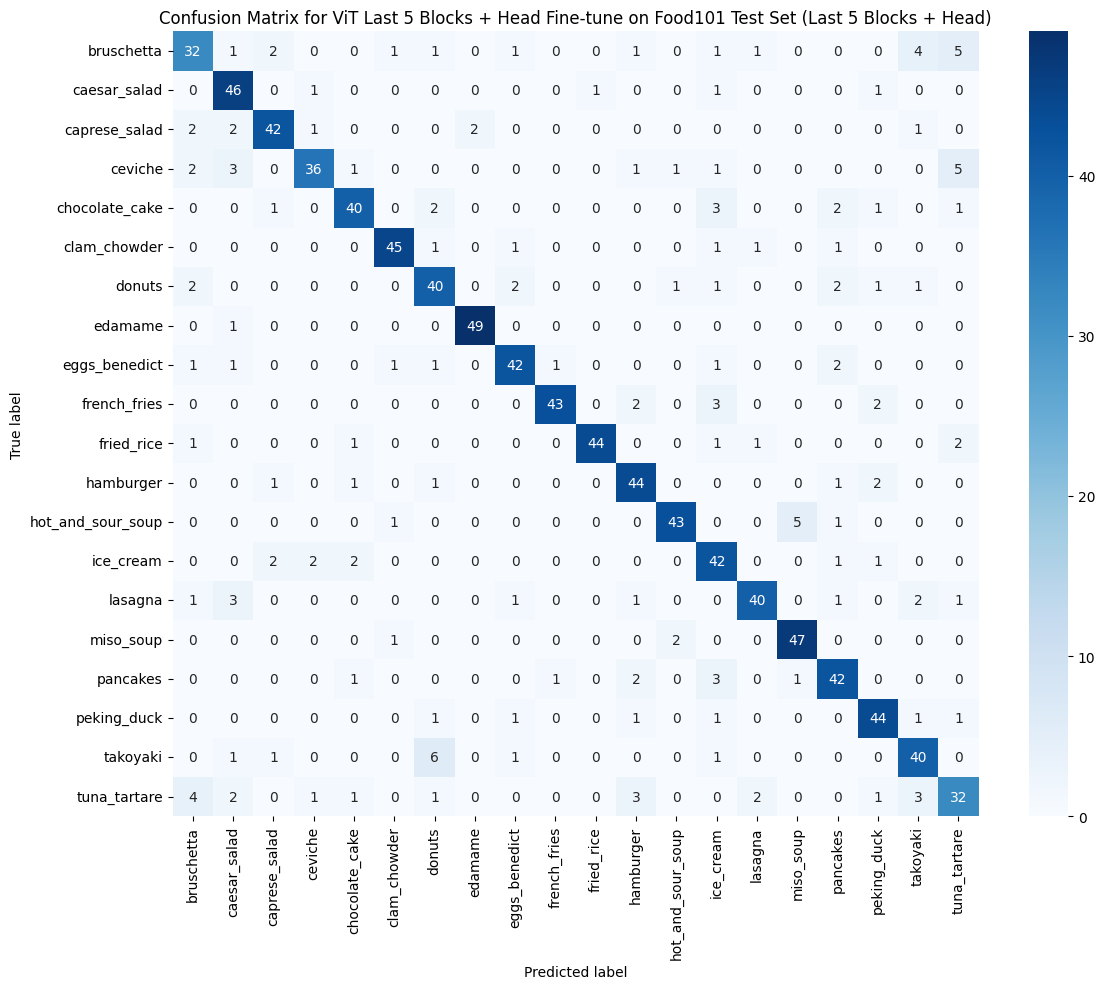


--- Per-class metrics for ViT Last 5 Blocks + Head Fine-tune ---

Top 10 weakest classes by F1-score:


,precision,recall,f1-score,support
tuna_tartare,0.6809,0.64,0.6598,50.0
bruschetta,0.7111,0.64,0.6737,50.0
ice_cream,0.7000,0.84,0.7636,50.0
donuts,0.7407,0.80,0.7692,50.0
takoyaki,0.7692,0.80,0.7843,50.0
ceviche,0.8780,0.72,0.7912,50.0
pancakes,0.7925,0.84,0.8155,50.0
chocolate_cake,0.8511,0.80,0.8247,50.0
caesar_salad,0.7667,0.92,0.8364,50.0
hamburger,0.8000,0.88,0.8381,50.0



Top 10 strongest classes by F1-score:


,precision,recall,f1-score,support
edamame,0.9608,0.98,0.9703,50.0
fried_rice,0.9778,0.88,0.9263,50.0
miso_soup,0.8868,0.94,0.9126,50.0
clam_chowder,0.9184,0.90,0.9091,50.0
french_fries,0.9556,0.86,0.9053,50.0
hot_and_sour_soup,0.9149,0.86,0.8866,50.0
peking_duck,0.8302,0.88,0.8544,50.0
caprese_salad,0.8571,0.84,0.8485,50.0
eggs_benedict,0.8571,0.84,0.8485,50.0
lasagna,0.8889,0.80,0.8421,50.0


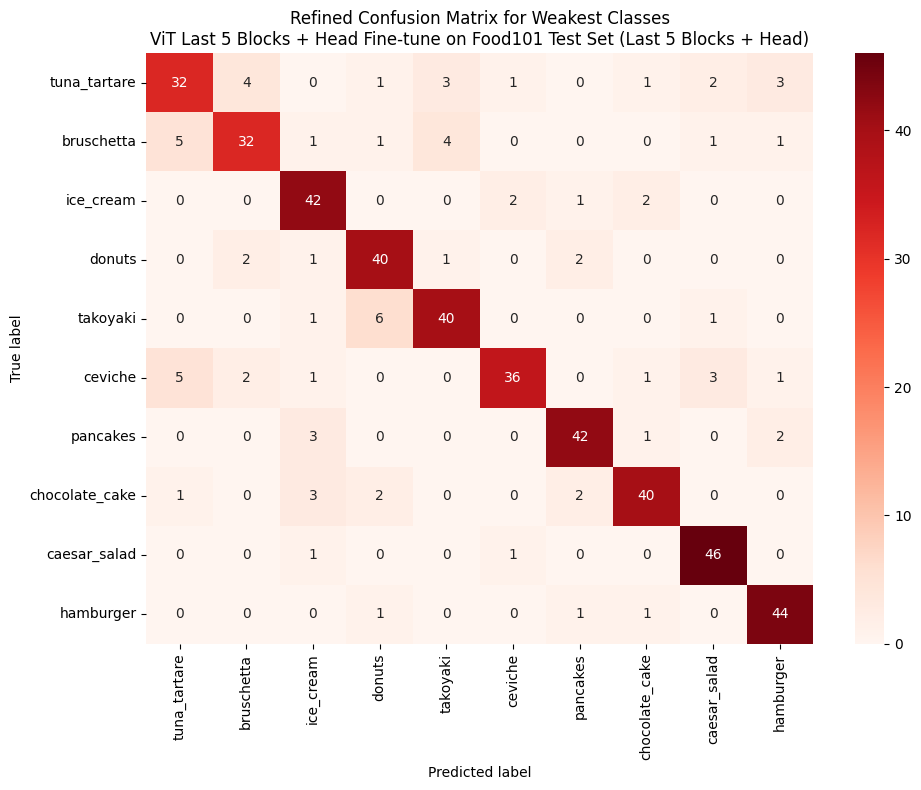

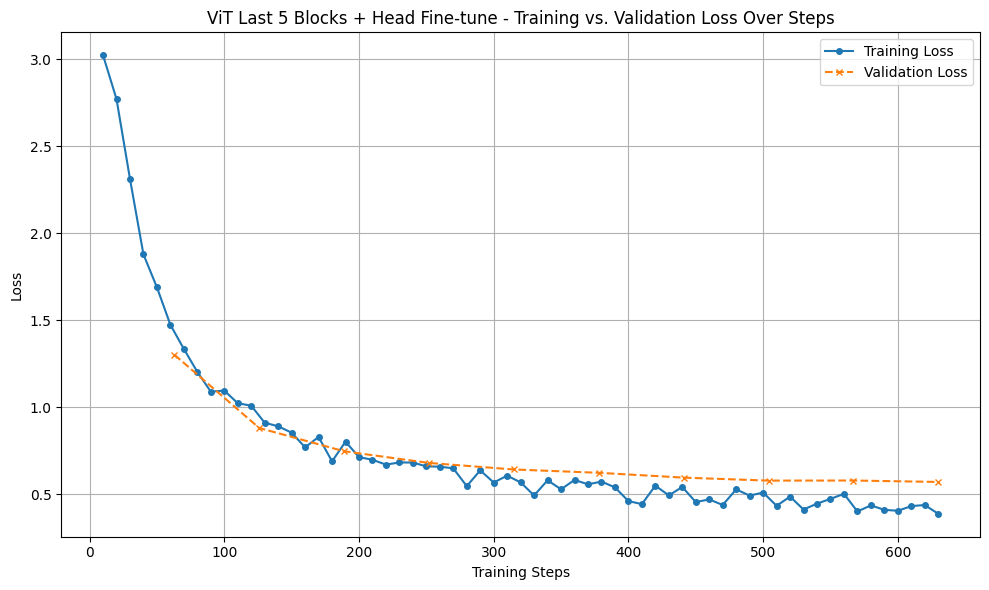

In [35]:
print("Trainable parameters for Last 5 Blocks + Head Fine-tuning:")
count_parameters(model_last_5_blocks)

last_5_blocks_metrics_food101 = evaluate_and_plot(
    model=model_last_5_blocks,
    trainer=trainer_last_5_blocks,
    dataset=food_vit["test"],
    id2label_mapping=id2label,
    dataset_name="Food101 Test Set (Last 5 Blocks + Head)",
    num_labels=len(id2label),
    model_display_name="ViT Last 5 Blocks + Head Fine-tune",
    training_time=vit_last_5_blocks_train_time
)

## ResNet-50 Full Model Fine-tuning (using `transformers`)

This section will fine-tune a ResNet-50 model using the `AutoImageProcessor` and `AutoModelForImageClassification` from Hugging Face `transformers`, ensuring appropriate preprocessing and consistent training parameters.

In [36]:
from transformers import AutoImageProcessor, AutoModelForImageClassification

# ResNet-50 Specific Preprocessing
resnet_model_id_hf = "microsoft/resnet-50"

# Load the image processor
resnet_image_processor = AutoImageProcessor.from_pretrained(resnet_model_id_hf)

# Apply ResNet-specific transforms to the already split 'food' dataset using the unified function
food_resnet = food.copy() # Create a copy to avoid modifying the original 'food' dataset directly
food_resnet["train"] = food_resnet["train"].with_transform(lambda examples: apply_transforms(examples, resnet_image_processor, is_train=True))
food_resnet["test"] = food_resnet["test"].with_transform(lambda examples: apply_transforms(examples, resnet_image_processor, is_train=False))

print("ResNet-50 specific image processor and transforms defined and applied to the shared dataset split using the unified function.")

preprocessor_config.json:   0%|          | 0.00/266 [00:00<?, ?B/s]

ResNet-50 specific image processor and transforms defined and applied to the shared dataset split using the unified function.


In [37]:
# Load the ResNet-50 model from Hugging Face Transformers
resnet_model_hf = AutoModelForImageClassification.from_pretrained(
    resnet_model_id_hf,
    num_labels=len(labels),
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True  # Set this to True to ignore mismatched sizes
)

# Ensure all parameters require gradients for full fine-tuning
for param in resnet_model_hf.parameters():
    param.requires_grad = True

print("ResNet-50 model loaded and configured for full fine-tuning.")
print(resnet_model_hf)

config.json:   0%|          | 0.00/69.6k [00:00<?, ?B/s]

[transformers] You passed `num_labels=20` which is incompatible to the `id2label` map of length `1000`.


model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]

[transformers] ResNetForImageClassification LOAD REPORT from: microsoft/resnet-50
Key                 | Status   |                                                                                             
--------------------+----------+---------------------------------------------------------------------------------------------
classifier.1.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 2048]) vs model:torch.Size([20, 2048])
classifier.1.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([20])            

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


ResNet-50 model loaded and configured for full fine-tuning.
ResNetForImageClassification(
  (resnet): ResNetModel(
    (embedder): ResNetEmbeddings(
      (embedder): ResNetConvLayer(
        (convolution): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
        (normalization): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (activation): ReLU()
      )
      (pooler): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    )
    (encoder): ResNetEncoder(
      (stages): ModuleList(
        (0): ResNetStage(
          (layers): Sequential(
            (0): ResNetBottleNeckLayer(
              (shortcut): ResNetShortCut(
                (convolution): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
                (normalization): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              )
              (layer): Sequential(
                (0):

In [38]:
from transformers import TrainingArguments, Trainer

# Define TrainingArguments for ResNet-50
training_args_resnet_hf = TrainingArguments(
    output_dir="/content/drive/MyDrive/ViTExperiments/food101_20cls_250_resnet50_full_finetune",
    remove_unused_columns=False,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=1e-4,
    per_device_train_batch_size=training_args_full.per_device_train_batch_size,
    gradient_accumulation_steps=training_args_full.gradient_accumulation_steps,
    per_device_eval_batch_size=training_args_full.per_device_eval_batch_size,
    num_train_epochs=training_args_full.num_train_epochs,
    warmup_steps=training_args_full.warmup_steps,
    logging_steps=training_args_full.logging_steps,
    run_name="food101_resnet50_hf_full_finetune",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    push_to_hub=False,
)

# Initialize the Trainer for ResNet-50
trainer_resnet_hf = Trainer(
    model=resnet_model_hf,
    args=training_args_resnet_hf,
    data_collator=data_collator,
    train_dataset=food_resnet["train"],
    eval_dataset=food_resnet["test"],
    processing_class=resnet_image_processor,
    compute_metrics=compute_metrics,
)

print("Starting ResNet-50 (Hugging Face) full model fine-tuning...")
resnet_hf_full_train_time = conditional_train_model(resnet_model_hf, trainer_resnet_hf, training_args_resnet_hf, "ResNet-50 HF Full Fine-tune")
print("ResNet-50 (Hugging Face) full model fine-tuning complete.")


Starting ResNet-50 (Hugging Face) full model fine-tuning...

--- Conditional training check for ResNet-50 HF Full Fine-tune ---
Output directory: /content/drive/MyDrive/ViTExperiments/food101_20cls_250_resnet50_full_finetune
FORCE_FINE_TUNING: True
Final model exists at root: False
Latest checkpoint: None
Latest checkpoint has weights: False
Starting fresh fine-tuning for ResNet-50 HF Full Fine-tune.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1,F1,Top 5 Accuracy,Mean Top1 Confidence,Mean Top1 Top2 Margin,Correct Mean Confidence,Wrong Mean Confidence,Ece,Nll,Brier Score
1,11.749966,2.921588,0.266000,0.252046,0.252046,0.252046,0.655000,0.057420,0.002093,0.058592,0.056996,0.208580,2.921588,0.942293
2,11.243346,2.748148,0.462000,0.449636,0.449636,0.449636,0.841000,0.069166,0.007850,0.073852,0.065143,0.392834,2.748148,0.921246
3,10.305348,2.431633,0.584000,0.567722,0.567722,0.567722,0.886000,0.110858,0.039450,0.130850,0.082792,0.473142,2.431633,0.857876
4,9.052301,2.034895,0.628000,0.617556,0.617556,0.617556,0.915000,0.201650,0.113912,0.252689,0.115488,0.426350,2.034895,0.749997
5,8.089225,1.752419,0.652000,0.640969,0.640969,0.640969,0.914000,0.282215,0.180476,0.353705,0.148275,0.369785,1.752419,0.666403
6,7.228958,1.564970,0.673000,0.665084,0.665084,0.665084,0.919000,0.336594,0.226876,0.414039,0.177205,0.336406,1.564970,0.608561
7,7.133093,1.451509,0.687000,0.681181,0.681181,0.681181,0.917000,0.375224,0.261788,0.458647,0.192120,0.311776,1.451509,0.569164
8,6.667068,1.341192,0.686000,0.682331,0.682331,0.682331,0.923000,0.414064,0.294177,0.505975,0.213266,0.271936,1.341192,0.529831
9,6.487041,1.306288,0.703000,0.699023,0.699023,0.699023,0.933000,0.425792,0.306077,0.511782,0.222252,0.277208,1.306288,0.516727
10,5.767901,1.316638,0.691000,0.687896,0.687896,0.687896,0.928000,0.419521,0.300190,0.510774,0.215458,0.271479,1.316638,0.519589


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training complete for ResNet-50 HF Full Fine-tune.
Train runtime: 737.51 seconds
Saving final model for ResNet-50 HF Full Fine-tune to: /content/drive/MyDrive/ViTExperiments/food101_20cls_250_resnet50_full_finetune


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved train metrics to: /content/drive/MyDrive/ViTExperiments/food101_20cls_250_resnet50_full_finetune/train_metrics.json
ResNet-50 (Hugging Face) full model fine-tuning complete.


### Evaluate ResNet-50 (Hugging Face) Full Fine-tuned Model

Trainable parameters for ResNet-50 (Hugging Face) Full Model Fine-tuning:
Number of trainable parameters: 23,549,012 (23.55 million)
Total parameters: 23,549,012 (23.55 million)

--- Evaluating ResNet-50 HF Full Fine-tune on Food101 Test Set (ResNet-50 HF Full Fine-tune) ---



Core metrics:
Accuracy:                0.7030
Macro F1:                0.6990
Weighted F1:             0.6990
Top-5 Accuracy:          0.9330
Eval Loss:               1.3063

Confidence / calibration metrics:
Mean Top-1 Confidence:   0.4258
Mean Top1-Top2 Margin:   0.3061
Correct Mean Confidence: 0.5118
Wrong Mean Confidence:   0.2223
ECE:                     0.2772
NLL:                     1.3063
Brier Score:             0.5167

Training time for ResNet-50 HF Full Fine-tune: 737.51 seconds

Label sanity check:
Number of unique true labels:      20
Number of unique predicted labels: 20

Confidence summary:


top1_confidence                               top1_top2_margin  \
                   mean  median     min     max count             mean   
correct                                                                  
False            0.2223  0.1902  0.0900  0.7912   297           0.0765   
True             0.5118  0.4497  0.0869  0.9977   703           0.4031   

                                       
         median     min     max count  
correct                                
False    0.0453  0.0000  0.6374   297  
True     0.3202  0.0008  0.9970   703


Most confident wrong predictions:


,true_label_id,pred_label_id,true_label,pred_label,top1_confidence,top2_confidence,top1_top2_margin,correct
722,11,9,hamburger,french_fries,0.7912,0.1537,0.6374,False
465,15,5,miso_soup,clam_chowder,0.6868,0.2123,0.4745,False
973,15,5,miso_soup,clam_chowder,0.6858,0.2613,0.4245,False
588,10,14,fried_rice,lasagna,0.6722,0.1020,0.5703,False
399,3,7,ceviche,edamame,0.6252,0.1204,0.5048,False
662,16,6,pancakes,donuts,0.5447,0.1140,0.4307,False
392,11,9,hamburger,french_fries,0.5401,0.1486,0.3914,False
845,1,10,caesar_salad,fried_rice,0.5322,0.1010,0.4312,False
310,15,12,miso_soup,hot_and_sour_soup,0.4882,0.3457,0.1425,False
746,18,6,takoyaki,donuts,0.4843,0.1516,0.3327,False



Lowest-margin predictions:


,true_label_id,pred_label_id,true_label,pred_label,top1_confidence,top2_confidence,top1_top2_margin,correct
395,16,4,pancakes,chocolate_cake,0.0987,0.0986,0.0000,False
618,0,6,bruschetta,donuts,0.1252,0.1250,0.0002,False
901,2,19,caprese_salad,tuna_tartare,0.2589,0.2586,0.0004,False
119,4,15,chocolate_cake,miso_soup,0.1461,0.1455,0.0006,False
482,13,13,ice_cream,ice_cream,0.1112,0.1103,0.0008,True
500,3,3,ceviche,ceviche,0.0967,0.0959,0.0008,True
902,4,19,chocolate_cake,tuna_tartare,0.1136,0.1127,0.0010,False
533,13,6,ice_cream,donuts,0.2080,0.2070,0.0010,False
631,18,4,takoyaki,chocolate_cake,0.0978,0.0967,0.0011,False
64,0,0,bruschetta,bruschetta,0.1457,0.1442,0.0015,True


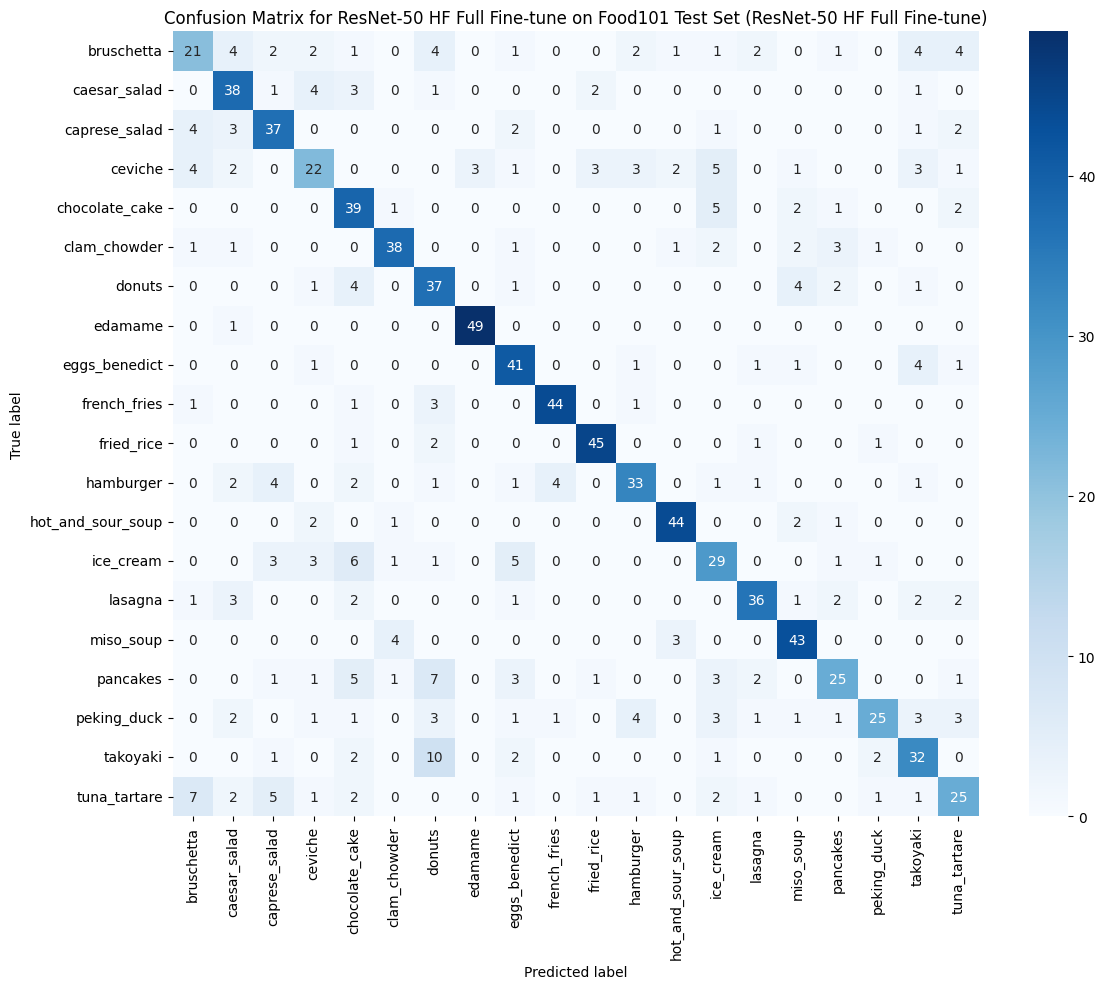


--- Per-class metrics for ResNet-50 HF Full Fine-tune ---

Top 10 weakest classes by F1-score:


,precision,recall,f1-score,support
bruschetta,0.5385,0.42,0.4719,50.0
ceviche,0.5789,0.44,0.5000,50.0
tuna_tartare,0.6098,0.50,0.5495,50.0
ice_cream,0.5472,0.58,0.5631,50.0
pancakes,0.6757,0.50,0.5747,50.0
peking_duck,0.8065,0.50,0.6173,50.0
takoyaki,0.6038,0.64,0.6214,50.0
donuts,0.5362,0.74,0.6218,50.0
chocolate_cake,0.5652,0.78,0.6555,50.0
hamburger,0.7333,0.66,0.6947,50.0



Top 10 strongest classes by F1-score:


,precision,recall,f1-score,support
edamame,0.9423,0.98,0.9608,50.0
french_fries,0.8980,0.88,0.8889,50.0
fried_rice,0.8654,0.90,0.8824,50.0
hot_and_sour_soup,0.8627,0.88,0.8713,50.0
miso_soup,0.7544,0.86,0.8037,50.0
clam_chowder,0.8261,0.76,0.7917,50.0
lasagna,0.8000,0.72,0.7579,50.0
eggs_benedict,0.6721,0.82,0.7387,50.0
caprese_salad,0.6852,0.74,0.7115,50.0
caesar_salad,0.6552,0.76,0.7037,50.0


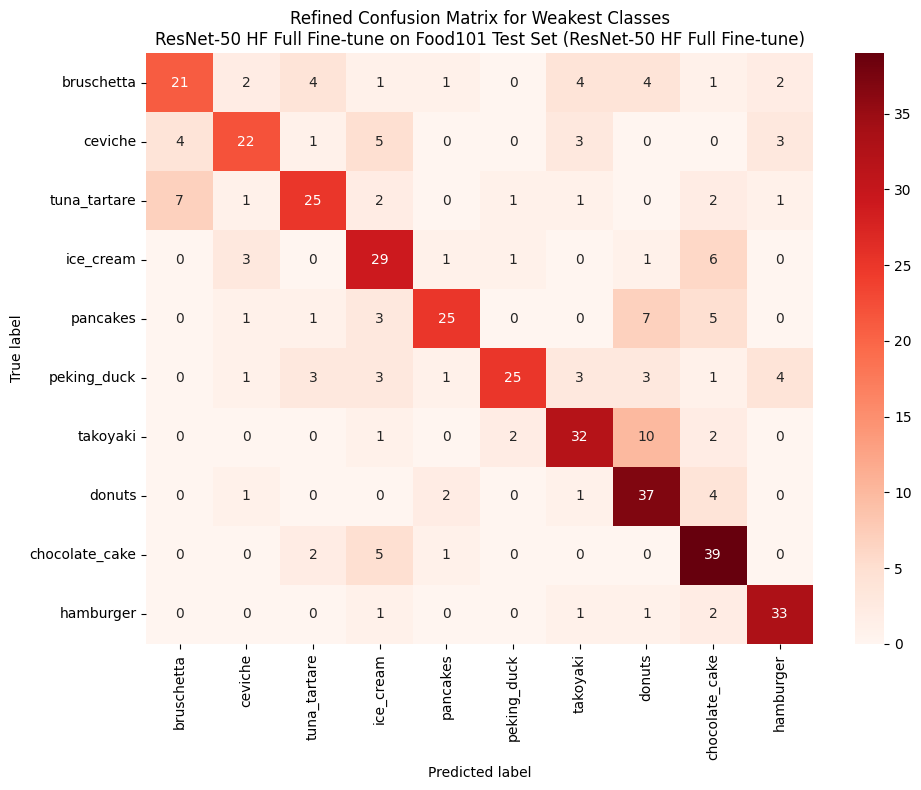

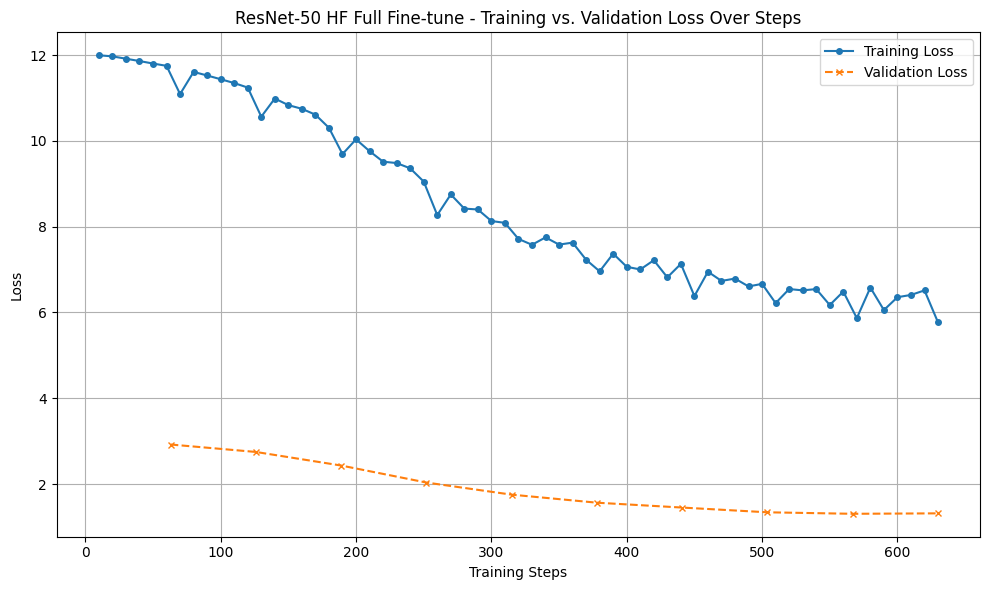

In [39]:
print("Trainable parameters for ResNet-50 (Hugging Face) Full Model Fine-tuning:")
count_parameters(resnet_model_hf)

resnet_hf_full_metrics_food101 = evaluate_and_plot(
    model=resnet_model_hf,
    trainer=trainer_resnet_hf,
    dataset=food_resnet["test"],
    id2label_mapping=id2label,
    dataset_name="Food101 Test Set (ResNet-50 HF Full Fine-tune)",
    num_labels=len(id2label),
    model_display_name="ResNet-50 HF Full Fine-tune",
    training_time=resnet_hf_full_train_time
)

## Summary of Fine-tuning Experiment Results on Food101

In [43]:
import pandas as pd

results_data = [
    {
        "Strategy": "ViT Head-Only Fine-tune",
        "Trainable Parameters (millions)": round(sum(p.numel() for p in model.parameters() if p.requires_grad) / 1e6, 2),
        "Number of Epochs": training_args.num_train_epochs,
        "Learning Rate": training_args.learning_rate,
        "Training Time (seconds)": vit_head_only_train_time,
        "Accuracy": head_only_metrics_food101["accuracy"],
        "Macro F1": head_only_metrics_food101["macro_f1"],
        "Weighted F1": head_only_metrics_food101["weighted_f1"],
        "Top-5 Accuracy": head_only_metrics_food101["top_5_accuracy"],
        "Eval Loss": head_only_metrics_food101.get("eval_loss", None),
        "Mean Confidence": head_only_metrics_food101["mean_top1_confidence"],
        "Mean Margin": head_only_metrics_food101["mean_top1_top2_margin"],
        "ECE": head_only_metrics_food101["ece"],
        "NLL": head_only_metrics_food101["nll"],
        "Brier Score": head_only_metrics_food101["brier_score"],
    },
    {
        "Strategy": "ViT Full Fine-tune",
        "Trainable Parameters (millions)": round(sum(p.numel() for p in model_full_finetune.parameters() if p.requires_grad) / 1e6, 2),
        "Number of Epochs": training_args_full.num_train_epochs,
        "Learning Rate": training_args_full.learning_rate,
        "Training Time (seconds)": vit_full_train_time,
        "Accuracy": full_finetune_metrics_food101["accuracy"],
        "Macro F1": full_finetune_metrics_food101["macro_f1"],
        "Weighted F1": full_finetune_metrics_food101["weighted_f1"],
        "Top-5 Accuracy": full_finetune_metrics_food101["top_5_accuracy"],
        "Eval Loss": full_finetune_metrics_food101.get("eval_loss", None),
        "Mean Confidence": full_finetune_metrics_food101["mean_top1_confidence"],
        "Mean Margin": full_finetune_metrics_food101["mean_top1_top2_margin"],
        "ECE": full_finetune_metrics_food101["ece"],
        "NLL": full_finetune_metrics_food101["nll"],
        "Brier Score": full_finetune_metrics_food101["brier_score"],
    },
    {
        "Strategy": "ViT LoRA Fine-tune",
        "Trainable Parameters (millions)": round(sum(p.numel() for p in model_lora.parameters() if p.requires_grad) / 1e6, 2),
        "Number of Epochs": training_args_lora.num_train_epochs,
        "Learning Rate": training_args_lora.learning_rate,
        "Training Time (seconds)": vit_lora_train_time,
        "Accuracy": lora_metrics_food101["accuracy"],
        "Macro F1": lora_metrics_food101["macro_f1"],
        "Weighted F1": lora_metrics_food101["weighted_f1"],
        "Top-5 Accuracy": lora_metrics_food101["top_5_accuracy"],
        "Eval Loss": lora_metrics_food101.get("eval_loss", None),
        "Mean Confidence": lora_metrics_food101["mean_top1_confidence"],
        "Mean Margin": lora_metrics_food101["mean_top1_top2_margin"],
        "ECE": lora_metrics_food101["ece"],
        "NLL": lora_metrics_food101["nll"],
        "Brier Score": lora_metrics_food101["brier_score"],
    },
    {
        "Strategy": "ViT Last 3 Blocks + Head Fine-tune",
        "Trainable Parameters (millions)": round(sum(p.numel() for p in model_last_3_blocks.parameters() if p.requires_grad) / 1e6, 2),
        "Number of Epochs": training_args_last_3_blocks.num_train_epochs,
        "Learning Rate": training_args_last_3_blocks.learning_rate,
        "Training Time (seconds)": vit_last_3_blocks_train_time,
        "Accuracy": last_3_blocks_metrics_food101["accuracy"],
        "Macro F1": last_3_blocks_metrics_food101["macro_f1"],
        "Weighted F1": last_3_blocks_metrics_food101["weighted_f1"],
        "Top-5 Accuracy": last_3_blocks_metrics_food101["top_5_accuracy"],
        "Eval Loss": last_3_blocks_metrics_food101.get("eval_loss", None),
        "Mean Confidence": last_3_blocks_metrics_food101["mean_top1_confidence"],
        "Mean Margin": last_3_blocks_metrics_food101["mean_top1_top2_margin"],
        "ECE": last_3_blocks_metrics_food101["ece"],
        "NLL": last_3_blocks_metrics_food101["nll"],
        "Brier Score": last_3_blocks_metrics_food101["brier_score"],
    },
    {
        "Strategy": "ViT Last 5 Blocks + Head Fine-tune",
        "Trainable Parameters (millions)": round(sum(p.numel() for p in model_last_5_blocks.parameters() if p.requires_grad) / 1e6, 2),
        "Number of Epochs": training_args_last_5_blocks.num_train_epochs,
        "Learning Rate": training_args_last_5_blocks.learning_rate,
        "Training Time (seconds)": vit_last_5_blocks_train_time,
        "Accuracy": last_5_blocks_metrics_food101["accuracy"],
        "Macro F1": last_5_blocks_metrics_food101["macro_f1"],
        "Weighted F1": last_5_blocks_metrics_food101["weighted_f1"],
        "Top-5 Accuracy": last_5_blocks_metrics_food101["top_5_accuracy"],
        "Eval Loss": last_5_blocks_metrics_food101.get("eval_loss", None),
        "Mean Confidence": last_5_blocks_metrics_food101["mean_top1_confidence"],
        "Mean Margin": last_5_blocks_metrics_food101["mean_top1_top2_margin"],
        "ECE": last_5_blocks_metrics_food101["ece"],
        "NLL": last_5_blocks_metrics_food101["nll"],
        "Brier Score": last_5_blocks_metrics_food101["brier_score"],
    },
]

# Add ResNet if it has already been evaluated
if "resnet_hf_full_metrics_food101" in globals():
    results_data.append(
        {
            "Strategy": "ResNet-50 HF Full Fine-tune",
            "Trainable Parameters (millions)": round(sum(p.numel() for p in resnet_model_hf.parameters() if p.requires_grad) / 1e6, 2),
            "Number of Epochs": training_args_resnet_hf.num_train_epochs,
            "Learning Rate": training_args_resnet_hf.learning_rate,
            "Training Time (seconds)": resnet_hf_full_train_time,
            "Accuracy": resnet_hf_full_metrics_food101["accuracy"],
            "Macro F1": resnet_hf_full_metrics_food101["macro_f1"],
            "Weighted F1": resnet_hf_full_metrics_food101["weighted_f1"],
            "Top-5 Accuracy": resnet_hf_full_metrics_food101["top_5_accuracy"],
            "Eval Loss": resnet_hf_full_metrics_food101.get("eval_loss", None),
            "Mean Confidence": resnet_hf_full_metrics_food101["mean_top1_confidence"],
            "Mean Margin": resnet_hf_full_metrics_food101["mean_top1_top2_margin"],
            "ECE": resnet_hf_full_metrics_food101["ece"],
            "NLL": resnet_hf_full_metrics_food101["nll"],
            "Brier Score": resnet_hf_full_metrics_food101["brier_score"],
        }
    )

results_df = pd.DataFrame(results_data)
results_df = results_df.sort_values(by="Accuracy", ascending=False).reset_index(drop=True)
display(results_df.round(4))

,Strategy,Trainable Parameters (millions),Number of Epochs,Learning Rate,Training Time (seconds),Accuracy,Macro F1,Weighted F1,Top-5 Accuracy,Eval Loss,Mean Confidence,Mean Margin,ECE,NLL,Brier Score
0,ViT Last 5 Blocks + Head Fine-tune,2.23,10,0.0001,333.4977,0.833,0.8330,0.8330,0.970,0.5703,0.8108,0.7377,0.0345,0.5703,0.2332
1,ViT Last 3 Blocks + Head Fine-tune,1.34,10,0.0001,324.6542,0.816,0.8158,0.8158,0.961,0.6534,0.7582,0.6671,0.0616,0.6534,0.2625
2,ViT Full Fine-tune,5.53,10,0.0000,422.5413,0.793,0.7929,0.7929,0.957,0.7729,0.6746,0.5650,0.1184,0.7729,0.3088
3,ViT LoRA Fine-tune,0.08,10,0.0002,370.1794,0.754,0.7506,0.7506,0.951,0.8922,0.6289,0.4946,0.1274,0.8922,0.3685
4,ViT Head-Only Fine-tune,0.00,10,0.0010,310.7741,0.740,0.7366,0.7366,0.947,0.9417,0.6137,0.4802,0.1263,0.9417,0.3926
5,ResNet-50 HF Full Fine-tune,23.55,10,0.0001,737.5119,0.703,0.6990,0.6990,0.933,1.3063,0.4258,0.3061,0.2772,1.3063,0.5167


## ConvNext tiny Full Model Fine-tuning (using `transformers`)

This section will fine-tune a ConvNext model using the `AutoImageProcessor` and `AutoModelForImageClassification` from Hugging Face `transformers`, ensuring appropriate preprocessing and consistent training parameters.

In [47]:
from transformers import AutoImageProcessor, AutoModelForImageClassification

# ConvNeXt-Tiny model from Hugging Face
convnext_model_id_hf = "facebook/convnext-tiny-224"

# Load the ConvNeXt-specific image processor
convnext_image_processor = AutoImageProcessor.from_pretrained(convnext_model_id_hf)

# Apply ConvNeXt-specific transforms to the already split balanced Food101 subset
food_convnext = food.copy()

food_convnext["train"] = food_convnext["train"].with_transform(
    lambda examples: apply_transforms(
        examples,
        convnext_image_processor,
        is_train=True
    )
)

food_convnext["test"] = food_convnext["test"].with_transform(
    lambda examples: apply_transforms(
        examples,
        convnext_image_processor,
        is_train=False
    )
)

print("ConvNeXt-specific image processor and transforms defined and applied.")

ConvNeXt-specific image processor and transforms defined and applied.


In [48]:

# Load the ConvNeXt-Tiny model with a new 20-class classification head
convnext_model_hf = AutoModelForImageClassification.from_pretrained(
    convnext_model_id_hf,
    num_labels=len(labels),
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True
)

# Ensure all parameters require gradients for full fine-tuning
for param in convnext_model_hf.parameters():
    param.requires_grad = True

print("ConvNeXt-Tiny model loaded and configured for full fine-tuning.")
print(convnext_model_hf)

# Sanity checks
print("Number of labels:", convnext_model_hf.config.num_labels)
print("id2label length:", len(convnext_model_hf.config.id2label))
print("label2id length:", len(convnext_model_hf.config.label2id))

[transformers] You passed `num_labels=20` which is incompatible to the `id2label` map of length `1000`.


Loading weights:   0%|          | 0/182 [00:00<?, ?it/s]

[transformers] ConvNextForImageClassification LOAD REPORT from: facebook/convnext-tiny-224
Key               | Status   |                                                                                           
------------------+----------+-------------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([20])          
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([20, 768])

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


ConvNeXt-Tiny model loaded and configured for full fine-tuning.
ConvNextForImageClassification(
  (convnext): ConvNextModel(
    (embeddings): ConvNextEmbeddings(
      (patch_embeddings): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
      (layernorm): ConvNextLayerNorm((96,), eps=1e-06, elementwise_affine=True)
    )
    (encoder): ConvNextEncoder(
      (stages): ModuleList(
        (0): ConvNextStage(
          (downsampling_layer): ModuleList()
          (layers): ModuleList(
            (0-2): 3 x ConvNextLayer(
              (dwconv): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
              (layernorm): ConvNextLayerNorm((96,), eps=1e-06, elementwise_affine=True)
              (pwconv1): Linear(in_features=96, out_features=384, bias=True)
              (act): GELUActivation()
              (pwconv2): Linear(in_features=384, out_features=96, bias=True)
              (drop_path): Identity()
            )
          )
        )
        (1): ConvN

In [49]:
from transformers import TrainingArguments, Trainer

# Define TrainingArguments for ConvNeXt-Tiny full fine-tuning
training_args_convnext_hf = TrainingArguments(
    output_dir="/content/drive/MyDrive/ViTExperiments/food101_20cls_250_convnext_tiny_full_finetune",
    remove_unused_columns=False,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=1e-4,
    per_device_train_batch_size=training_args_full.per_device_train_batch_size,
    gradient_accumulation_steps=training_args_full.gradient_accumulation_steps,
    per_device_eval_batch_size=training_args_full.per_device_eval_batch_size,
    num_train_epochs=training_args_full.num_train_epochs,
    warmup_steps=training_args_full.warmup_steps,
    logging_steps=training_args_full.logging_steps,
    run_name="food101_convnext_tiny_full_finetune",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    push_to_hub=False,
)

# Initialize the Trainer for ConvNeXt-Tiny
trainer_convnext_hf = Trainer(
    model=convnext_model_hf,
    args=training_args_convnext_hf,
    data_collator=data_collator,
    train_dataset=food_convnext["train"],
    eval_dataset=food_convnext["test"],
    processing_class=convnext_image_processor,
    compute_metrics=compute_metrics,
)

print("Starting ConvNeXt-Tiny full model fine-tuning...")

convnext_hf_full_train_time = conditional_train_model(
    convnext_model_hf,
    trainer_convnext_hf,
    training_args_convnext_hf,
    "ConvNeXt-Tiny HF Full Fine-tune"
)

print("ConvNeXt-Tiny full model fine-tuning complete.")

Starting ConvNeXt-Tiny full model fine-tuning...

--- Conditional training check for ConvNeXt-Tiny HF Full Fine-tune ---
Output directory: /content/drive/MyDrive/ViTExperiments/food101_20cls_250_convnext_tiny_full_finetune
FORCE_FINE_TUNING: True
Final model exists at root: False
Latest checkpoint: None
Latest checkpoint has weights: False
Starting fresh fine-tuning for ConvNeXt-Tiny HF Full Fine-tune.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1,F1,Top 5 Accuracy,Mean Top1 Confidence,Mean Top1 Top2 Margin,Correct Mean Confidence,Wrong Mean Confidence,Ece,Nll,Brier Score
1,2.187138,1.994452,0.691000,0.685637,0.685637,0.685637,0.928000,0.173224,0.084650,0.201273,0.110499,0.517776,1.994452,0.757499
2,1.327993,1.137503,0.789000,0.785355,0.785355,0.785355,0.952000,0.440910,0.333624,0.498660,0.224960,0.348287,1.137503,0.451003
3,0.799086,0.787040,0.828000,0.827971,0.827971,0.827971,0.964000,0.611034,0.506690,0.669789,0.328189,0.216966,0.787040,0.306849
4,0.637401,0.636960,0.846000,0.847100,0.847100,0.847100,0.970000,0.703015,0.613493,0.760549,0.386956,0.142985,0.636960,0.248493
5,0.524751,0.545307,0.858000,0.857301,0.857301,0.857301,0.976000,0.758409,0.677380,0.813164,0.427566,0.099591,0.545307,0.214613
6,0.439446,0.495604,0.863000,0.862593,0.862593,0.862593,0.980000,0.786679,0.712693,0.841423,0.441831,0.082170,0.495604,0.198257
7,0.397095,0.458625,0.873000,0.872829,0.872829,0.872829,0.979000,0.805551,0.734035,0.857102,0.451192,0.067449,0.458626,0.184303
8,0.374108,0.443937,0.879000,0.879231,0.879231,0.879231,0.981000,0.815029,0.745756,0.861635,0.476461,0.064204,0.443937,0.179998
9,0.369352,0.434209,0.877000,0.876735,0.876735,0.876735,0.982000,0.821909,0.754243,0.869852,0.480072,0.055091,0.434209,0.177452
10,0.258834,0.425390,0.876000,0.876038,0.876038,0.876038,0.984000,0.827164,0.760537,0.876005,0.482131,0.051397,0.425390,0.174474


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training complete for ConvNeXt-Tiny HF Full Fine-tune.
Train runtime: 1081.18 seconds
Saving final model for ConvNeXt-Tiny HF Full Fine-tune to: /content/drive/MyDrive/ViTExperiments/food101_20cls_250_convnext_tiny_full_finetune


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved train metrics to: /content/drive/MyDrive/ViTExperiments/food101_20cls_250_convnext_tiny_full_finetune/train_metrics.json
ConvNeXt-Tiny full model fine-tuning complete.


Trainable parameters for ConvNeXt-Tiny HF Full Fine-tuning:
Number of trainable parameters: 27,835,508 (27.84 million)
Total parameters: 27,835,508 (27.84 million)

--- Evaluating ConvNeXt-Tiny HF Full Fine-tune on Food101 20-Class Validation Set ---



Core metrics:
Accuracy:                0.8790
Macro F1:                0.8792
Weighted F1:             0.8792
Top-5 Accuracy:          0.9810
Eval Loss:               0.4439

Confidence / calibration metrics:
Mean Top-1 Confidence:   0.8150
Mean Top1-Top2 Margin:   0.7458
Correct Mean Confidence: 0.8616
Wrong Mean Confidence:   0.4765
ECE:                     0.0642
NLL:                     0.4439
Brier Score:             0.1800

Training time for ConvNeXt-Tiny HF Full Fine-tune: 1081.18 seconds

Label sanity check:
Number of unique true labels:      20
Number of unique predicted labels: 20

Confidence summary:


top1_confidence                               top1_top2_margin  \
                   mean  median     min     max count             mean   
correct                                                                  
False            0.4765  0.4545  0.1167  0.9541   121           0.2939   
True             0.8616  0.9419  0.1918  0.9917   879           0.8080   

                                       
         median     min     max count  
correct                                
False    0.2292  0.0004  0.9392   121  
True     0.9239  0.0044  0.9905   879


Most confident wrong predictions:


,true_label_id,pred_label_id,true_label,pred_label,top1_confidence,top2_confidence,top1_top2_margin,correct
641,2,3,caprese_salad,ceviche,0.9541,0.0149,0.9392,False
798,3,19,ceviche,tuna_tartare,0.9374,0.0270,0.9104,False
67,11,17,hamburger,peking_duck,0.9182,0.0207,0.8975,False
719,19,0,tuna_tartare,bruschetta,0.9009,0.0382,0.8627,False
588,10,14,fried_rice,lasagna,0.8446,0.0456,0.7990,False
82,18,6,takoyaki,donuts,0.8290,0.0469,0.7821,False
428,0,18,bruschetta,takoyaki,0.8171,0.0401,0.7770,False
175,5,16,clam_chowder,pancakes,0.8014,0.0397,0.7616,False
166,15,12,miso_soup,hot_and_sour_soup,0.7874,0.1203,0.6671,False
917,2,0,caprese_salad,bruschetta,0.7751,0.1817,0.5934,False



Lowest-margin predictions:


,true_label_id,pred_label_id,true_label,pred_label,top1_confidence,top2_confidence,top1_top2_margin,correct
938,6,4,donuts,chocolate_cake,0.1846,0.1842,0.0004,False
803,10,3,fried_rice,ceviche,0.1167,0.1159,0.0008,False
210,0,11,bruschetta,hamburger,0.1844,0.1821,0.0023,False
446,18,18,takoyaki,takoyaki,0.4059,0.4016,0.0044,True
96,19,19,tuna_tartare,tuna_tartare,0.2892,0.2844,0.0048,True
158,16,16,pancakes,pancakes,0.2520,0.2438,0.0082,True
967,0,0,bruschetta,bruschetta,0.3858,0.3738,0.0120,True
970,2,2,caprese_salad,caprese_salad,0.1981,0.1855,0.0126,True
295,14,1,lasagna,caesar_salad,0.3682,0.3554,0.0128,False
633,14,5,lasagna,clam_chowder,0.3908,0.3680,0.0228,False


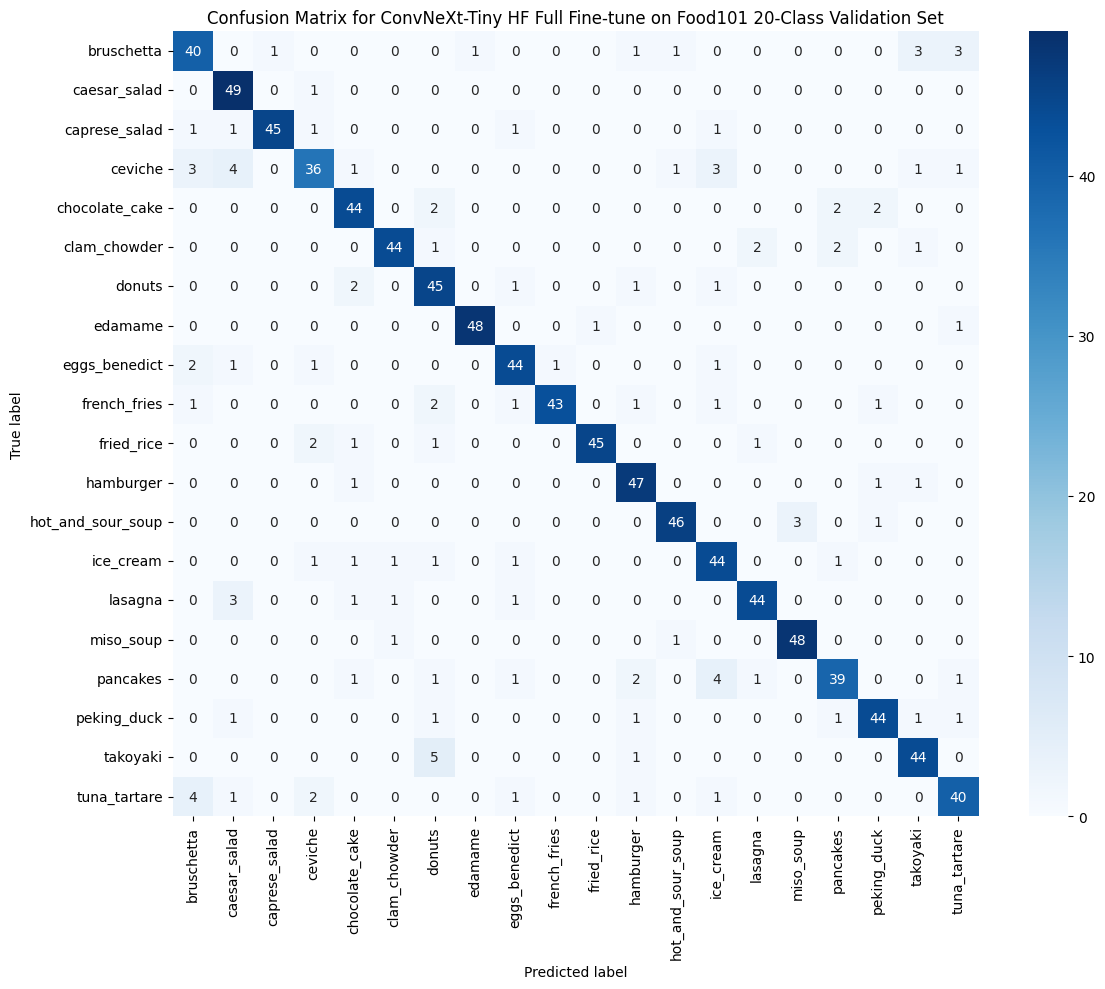


--- Per-class metrics for ConvNeXt-Tiny HF Full Fine-tune ---

Top 10 weakest classes by F1-score:


,precision,recall,f1-score,support
ceviche,0.8182,0.72,0.7660,50.0
bruschetta,0.7843,0.80,0.7921,50.0
pancakes,0.8667,0.78,0.8211,50.0
tuna_tartare,0.8511,0.80,0.8247,50.0
donuts,0.7627,0.90,0.8257,50.0
ice_cream,0.7857,0.88,0.8302,50.0
chocolate_cake,0.8462,0.88,0.8627,50.0
eggs_benedict,0.8627,0.88,0.8713,50.0
takoyaki,0.8627,0.88,0.8713,50.0
peking_duck,0.8980,0.88,0.8889,50.0



Top 10 strongest classes by F1-score:


,precision,recall,f1-score,support
edamame,0.9796,0.96,0.9697,50.0
miso_soup,0.9412,0.96,0.9505,50.0
caprese_salad,0.9783,0.90,0.9375,50.0
fried_rice,0.9783,0.90,0.9375,50.0
hot_and_sour_soup,0.9388,0.92,0.9293,50.0
french_fries,0.9773,0.86,0.9149,50.0
clam_chowder,0.9362,0.88,0.9072,50.0
lasagna,0.9167,0.88,0.8980,50.0
hamburger,0.8545,0.94,0.8952,50.0
caesar_salad,0.8167,0.98,0.8909,50.0


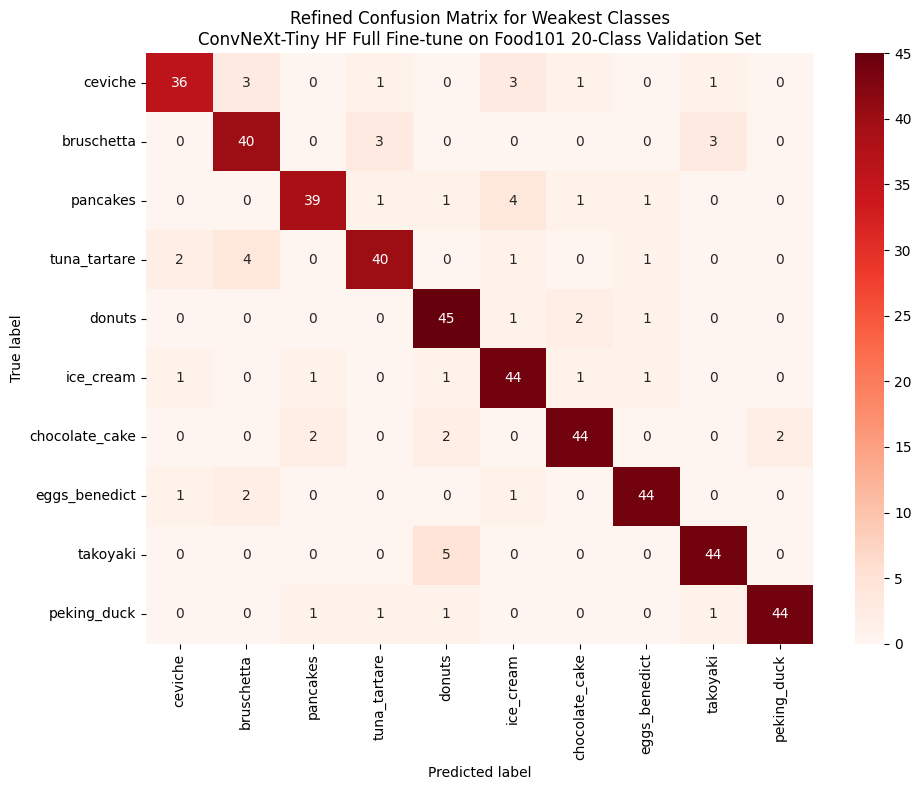

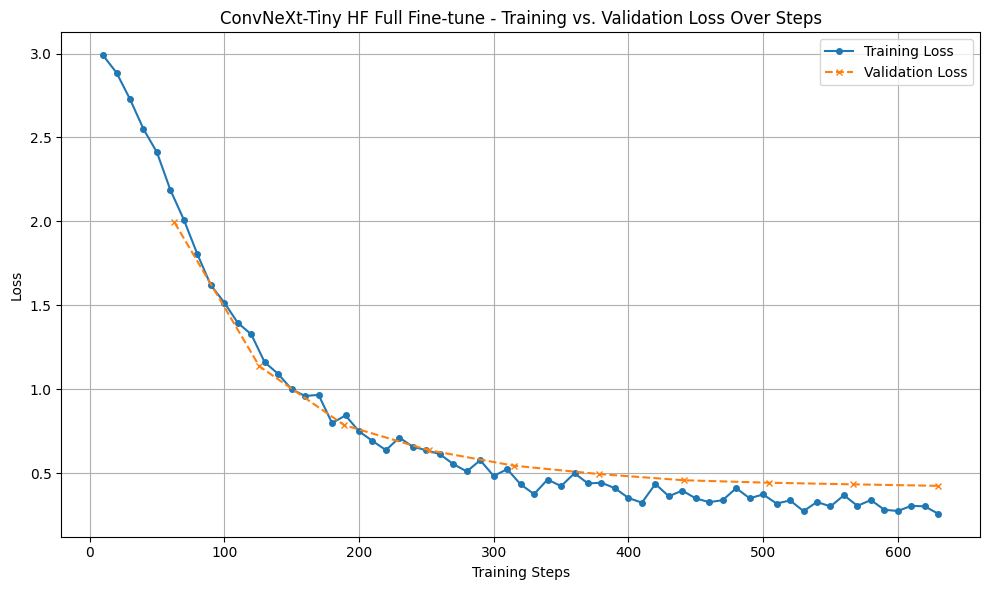

In [51]:
print("Trainable parameters for ConvNeXt-Tiny HF Full Fine-tuning:")
count_parameters(convnext_model_hf)

convnext_hf_full_metrics_food101 = evaluate_and_plot(
    model=convnext_model_hf,
    trainer=trainer_convnext_hf,
    dataset=food_convnext["test"],
    id2label_mapping=id2label,
    dataset_name="Food101 20-Class Validation Set",
    num_labels=len(id2label),
    model_display_name="ConvNeXt-Tiny HF Full Fine-tune",
    training_time=convnext_hf_full_train_time
)